In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

sub_list = ['Analytical', 'Master', 'Operational', 'Transaction']

for sub in sub_list:
    folder = '/content/drive/MyDrive/Datathon/' + sub + '/'
    files = os.listdir(folder)
    for f in files:
        if f.endswith('.csv'):
            df = pd.read_csv(folder + f)
            print(f, df.shape)

Mounted at /content/drive
sales.csv (3833, 3)
sample_submission.csv (548, 3)
products.csv (2412, 8)
customers.csv (121930, 7)
geography.csv (39948, 4)
promotions.csv (50, 10)
web_traffic.csv (3652, 7)
inventory.csv (60247, 17)


/tmp/ipykernel_727/3347018056.py:14: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(folder + f)


order_items.csv (714669, 7)
orders.csv (646945, 8)
reviews.csv (113551, 7)
returns.csv (39939, 7)
shipments.csv (566067, 4)
payments.csv (646945, 4)


In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
from google.colab import drive

# 1. Khởi tạo môi trường
warnings.filterwarnings('ignore')
drive.mount('/content/drive')

# Cấu hình đường dẫn gốc - Bạn có thể thay đổi path này tùy theo cấu trúc Drive của mình
BASE_PATH = '/content/drive/MyDrive/Datathon/'

# Danh sách các folder con chứa dữ liệu
SUB_FOLDERS = ['Analytical', 'Master', 'Operational', 'Transaction']

# Từ điển cấu hình các cột date cần parse cho từng file
DATE_COLUMNS_MAP = {
    'customers.csv': ['signup_date'],
    'promotions.csv': ['start_date', 'end_date'],
    'orders.csv': ['order_date'],
    'shipments.csv': ['ship_date', 'delivery_date'],
    'returns.csv': ['return_date'],
    'reviews.csv': ['review_date'],
    'sales.csv': ['Date'],
    'sales_test.csv': ['Date'],
    'inventory.csv': ['snapshot_date'],
    'web_traffic.csv': ['date']
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def load_datathon_datasets(base_path, sub_folders, date_map):
    """
    Hàm Smart Loading: Load toàn bộ CSV vào một Dictionary và ép kiểu date.
    """
    datasets = {}
    print("--- Bắt đầu load dữ liệu ---")

    for folder in sub_folders:
        folder_path = os.path.join(base_path, folder)
        if not os.path.exists(folder_path):
            print(f"[Cảnh báo] Thư mục không tồn tại: {folder_path}")
            continue

        files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

        for file_name in files:
            file_key = file_name.replace('.csv', '')
            full_file_path = os.path.join(folder_path, file_name)

            # Xác định các cột date cần parse
            parse_dates = date_map.get(file_name, False)

            try:
                df = pd.read_csv(full_file_path, parse_dates=parse_dates)
                datasets[file_key] = df
                print(f"[Thành công] Load {file_name} | Shape: {df.shape} | Date parsed: {parse_dates}")
            except Exception as e:
                print(f"[Lỗi] Không thể load {file_name}: {e}")

    return datasets

# Thực thi load dữ liệu
datasets = load_datathon_datasets(BASE_PATH, SUB_FOLDERS, DATE_COLUMNS_MAP)

--- Bắt đầu load dữ liệu ---
[Thành công] Load sales.csv | Shape: (3833, 3) | Date parsed: ['Date']
[Thành công] Load sample_submission.csv | Shape: (548, 3) | Date parsed: False
[Thành công] Load products.csv | Shape: (2412, 8) | Date parsed: False
[Thành công] Load customers.csv | Shape: (121930, 7) | Date parsed: ['signup_date']
[Thành công] Load geography.csv | Shape: (39948, 4) | Date parsed: False
[Thành công] Load promotions.csv | Shape: (50, 10) | Date parsed: ['start_date', 'end_date']
[Thành công] Load web_traffic.csv | Shape: (3652, 7) | Date parsed: ['date']
[Thành công] Load inventory.csv | Shape: (60247, 17) | Date parsed: ['snapshot_date']
[Thành công] Load order_items.csv | Shape: (714669, 7) | Date parsed: False
[Thành công] Load orders.csv | Shape: (646945, 8) | Date parsed: ['order_date']
[Thành công] Load reviews.csv | Shape: (113551, 7) | Date parsed: ['review_date']
[Thành công] Load returns.csv | Shape: (39939, 7) | Date parsed: ['return_date']
[Thành công] Load 

In [ ]:
def run_sanity_checks(datasets):
    """
    Hàm kiểm tra các ràng buộc logic kinh doanh (Sanity Checks).
    """
    print("\n--- BÁO CÁO KIỂM TRA RÀNG BUỘC DỮ LIỆU (SANITY CHECKS) ---")

    # Check 1: Products - Giá vốn vs Giá bán
    if 'products' in datasets:
        df_p = datasets['products']
        violation = df_p[df_p['cogs'] >= df_p['price']]
        print(f"1. [Products]: Có {len(violation)} dòng vi phạm cogs >= price.")
        if len(violation) > 0: display(violation.head(3))

    # Check 2: Shipments - Phí ship và Logic ngày tháng
    if 'shipments' in datasets:
        df_s = datasets['shipments']
        neg_fee = df_s[df_s['shipping_fee'] < 0]
        wrong_date = df_s[df_s['delivery_date'] < df_s['ship_date']]
        print(f"2. [Shipments]:")
        print(f"   - Số đơn hàng phí ship âm: {len(neg_fee)}")
        print(f"   - Số đơn hàng giao trước khi gửi (lỗi logic): {len(wrong_date)}")

    # Check 3: Cardinality Orders <-> Payments (1:1)
    if 'payments' in datasets:
        df_pay = datasets['payments']
        duplicates = df_pay.duplicated(subset=['order_id']).sum()
        print(f"3. [Cardinality]: Có {duplicates} order_id bị lặp trong payments.csv (Yêu cầu 1:1).")

# Chạy kiểm tra
run_sanity_checks(datasets)


--- BÁO CÁO KIỂM TRA RÀNG BUỘC DỮ LIỆU (SANITY CHECKS) ---
1. [Products]: Có 0 dòng vi phạm cogs >= price.
2. [Shipments]:
   - Số đơn hàng phí ship âm: 0
   - Số đơn hàng giao trước khi gửi (lỗi logic): 0
3. [Cardinality]: Có 0 order_id bị lặp trong payments.csv (Yêu cầu 1:1).


In [ ]:
import pandas as pd
import numpy as np

print("🎯 KẾT QUẢ PHẦN 1 - TRẮC NGHIỆM 🎯\n" + "-"*40)

# --- Q1. Trung vị số ngày giữa hai lần mua liên tiếp ---
# Bẫy: Phải sort theo khách hàng và ngày mua trước khi dùng hàm shift()
df_orders = datasets['orders'].sort_values(by=['customer_id', 'order_date'])
df_orders['prev_order_date'] = df_orders.groupby('customer_id')['order_date'].shift(1)
df_orders['gap_days'] = (df_orders['order_date'] - df_orders['prev_order_date']).dt.days
# Đề yêu cầu tính trên các khách hàng có >1 đơn hàng (gap_days sẽ không bị null)
q1_ans = df_orders['gap_days'].median()
print(f"Q1: Trung vị inter-order gap = {q1_ans} ngày")

# --- Q2. Phân khúc tỷ suất lợi nhuận gộp cao nhất ---
df_products = datasets['products'].copy()
df_products['gross_margin'] = (df_products['price'] - df_products['cogs']) / df_products['price']
q2_ans = df_products.groupby('segment')['gross_margin'].mean().idxmax()
print(f"Q2: Segment có lợi nhuận gộp cao nhất = {q2_ans}")

# --- Q3. Lý do trả hàng nhiều nhất cho Streetwear ---
merged_q3 = datasets['returns'].merge(datasets['products'], on='product_id')
streetwear_returns = merged_q3[merged_q3['category'] == 'Streetwear']
q3_ans = streetwear_returns['return_reason'].value_counts().idxmax()
print(f"Q3: Lý do trả hàng nhiều nhất (Streetwear) = {q3_ans}")

# --- Q4. Nguồn traffic có tỷ lệ thoát trung bình thấp nhất ---
q4_ans = datasets['web_traffic'].groupby('traffic_source')['bounce_rate'].mean().idxmin()
print(f"Q4: Nguồn traffic có tỷ lệ thoát thấp nhất = {q4_ans}")

# --- Q5. Tỷ lệ order_items có khuyến mãi ---
df_items = datasets['order_items']
promo_count = df_items['promo_id'].notnull().sum()
total_items = len(df_items)
q5_ans = (promo_count / total_items) * 100
print(f"Q5: Tỷ lệ dòng có áp dụng khuyến mãi = {q5_ans:.2f}%")

# --- Q6. Nhóm tuổi có số đơn hàng trung bình cao nhất ---
# Bẫy: Khách hàng chưa mua đơn nào (order count = 0) vẫn tính vào trung bình
df_cust = datasets['customers'].dropna(subset=['age_group'])
order_counts = datasets['orders'].groupby('customer_id').size().reset_index(name='order_count')
merged_q6 = df_cust.merge(order_counts, on='customer_id', how='left')
merged_q6['order_count'] = merged_q6['order_count'].fillna(0) # Khách chưa mua gán = 0
q6_ans = merged_q6.groupby('age_group')['order_count'].mean().idxmax()
print(f"Q6: Nhóm tuổi có số đơn trung bình cao nhất = {q6_ans}")

# --- Q7. Vùng tạo ra tổng doanh thu cao nhất ---
# Bẫy: Đề ghi "trong sales_train.csv" là nói về Giai đoạn thời gian, không phải trong bảng sales.
# Cần join order_items -> orders -> geography để lấy region.
df_items['revenue'] = (df_items['quantity'] * df_items['unit_price']) - df_items['discount_amount']
order_revenue = df_items.groupby('order_id')['revenue'].sum().reset_index()
merged_q7 = order_revenue.merge(datasets['orders'][['order_id', 'zip']], on='order_id')
merged_q7 = merged_q7.merge(datasets['geography'][['zip', 'region']], on='zip')
q7_ans = merged_q7.groupby('region')['revenue'].sum().idxmax()
print(f"Q7: Vùng tạo doanh thu cao nhất = {q7_ans}")

# --- Q8. Phương thức thanh toán nhiều nhất của đơn bị hủy (cancelled) ---
df_orders_cancelled = datasets['orders'][datasets['orders']['order_status'] == 'cancelled']

# Diagnostic print 1: Check columns of datasets['payments']
print(f"DEBUG Q8: Columns in datasets['payments']: {datasets['payments'].columns.tolist()}")

if 'payment_method' in datasets['payments'].columns:
    merged_q8 = df_orders_cancelled.merge(datasets['payments'], on='order_id', how='left') # Use left merge to keep all cancelled orders

    # Diagnostic print 2: Check columns of merged_q8 after merge
    print(f"DEBUG Q8: Columns in merged_q8 after merge: {merged_q8.columns.tolist()}")

    # The issue is that after merge, the column is renamed to 'payment_method_y'
    if 'payment_method_y' in merged_q8.columns:
        # Check for NaN values in payment_method_y after merge, might be why value_counts().idxmax() fails if all are NaN
        if merged_q8['payment_method_y'].isnull().all():
            print("Q8: Cột 'payment_method_y' tồn tại nhưng tất cả giá trị đều là NaN sau khi merge.")
            q8_ans = "N/A (All NaN)"
        else:
            q8_ans = merged_q8['payment_method_y'].value_counts().idxmax()
            print(f"Q8: Phương thức thanh toán bị huỷ nhiều nhất = {q8_ans}")
    else:
        print("Q8: Lỗi logic: Cột 'payment_method_y' không có trong merged_q8 dù có trong datasets['payments'].")
        q8_ans = "N/A (Merge did not transfer column correctly)"
else:
    print("Q8: Cột 'payment_method' không tồn tại trong datasets['payments'] trước khi merge.")
    q8_ans = "N/A (Column missing from source)"

# --- Q9. Kích thước (Size) có tỷ lệ trả hàng cao nhất ---
# Đề định nghĩa: số returns / số order_items
df_prod_sizes = datasets['products'][datasets['products']['size'].isin(['S', 'M', 'L', 'XL'])]
items_with_size = datasets['order_items'].merge(df_prod_sizes[['product_id', 'size']], on='product_id')
returns_with_size = datasets['returns'].merge(df_prod_sizes[['product_id', 'size']], on='product_id')

item_counts = items_with_size['size'].value_counts()
return_counts = returns_with_size['size'].value_counts()
return_rate = (return_counts / item_counts).dropna()
q9_ans = return_rate.idxmax()
print(f"Q9: Size có tỷ lệ trả hàng cao nhất = {q9_ans}")

# --- Q10. Kế hoạch trả góp có thanh toán trung bình cao nhất ---
q10_ans = datasets['payments'].groupby('installments')['payment_value'].mean().idxmax()
print(f"Q10: Kỳ trả góp có avg payment value cao nhất = {q10_ans} kỳ")
print("-" * 40)


🎯 KẾT QUẢ PHẦN 1 - TRẮC NGHIỆM 🎯
----------------------------------------
Q1: Trung vị inter-order gap = 144.0 ngày
Q2: Segment có lợi nhuận gộp cao nhất = Standard
Q3: Lý do trả hàng nhiều nhất (Streetwear) = wrong_size
Q4: Nguồn traffic có tỷ lệ thoát thấp nhất = email_campaign
Q5: Tỷ lệ dòng có áp dụng khuyến mãi = 38.66%
Q6: Nhóm tuổi có số đơn trung bình cao nhất = 55+
Q7: Vùng tạo doanh thu cao nhất = East
DEBUG Q8: Columns in datasets['payments']: ['order_id', 'payment_method', 'payment_value', 'installments']
DEBUG Q8: Columns in merged_q8 after merge: ['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method_x', 'device_type', 'order_source', 'payment_method_y', 'payment_value', 'installments']
Q8: Phương thức thanh toán bị huỷ nhiều nhất = credit_card
Q9: Size có tỷ lệ trả hàng cao nhất = S
Q10: Kỳ trả góp có avg payment value cao nhất = 6 kỳ
----------------------------------------


### Phase 2: Advanced Preprocessing, Feature Engineering & ABT Creation

--- Step 1: Handling Missing Values by Business Context ---
Summary of missing values after handling:
 - customers: 0 missing left
 - promotions: 0 missing left
 - order_items: 0 missing left

--- Step 2: Outlier Management (Capping at 1st & 99th Percentile) ---
 - Capped order_items.quantity to range: [1.00, 8.00]
 - Capped order_items.unit_price to range: [627.87, 15778.48]
 - Capped order_items.discount_amount to range: [0.00, 11041.15]
 - Capped shipments.shipping_fee to range: [0.04, 31.29]
 - Capped payments.payment_value to range: [1052.67, 98075.75]


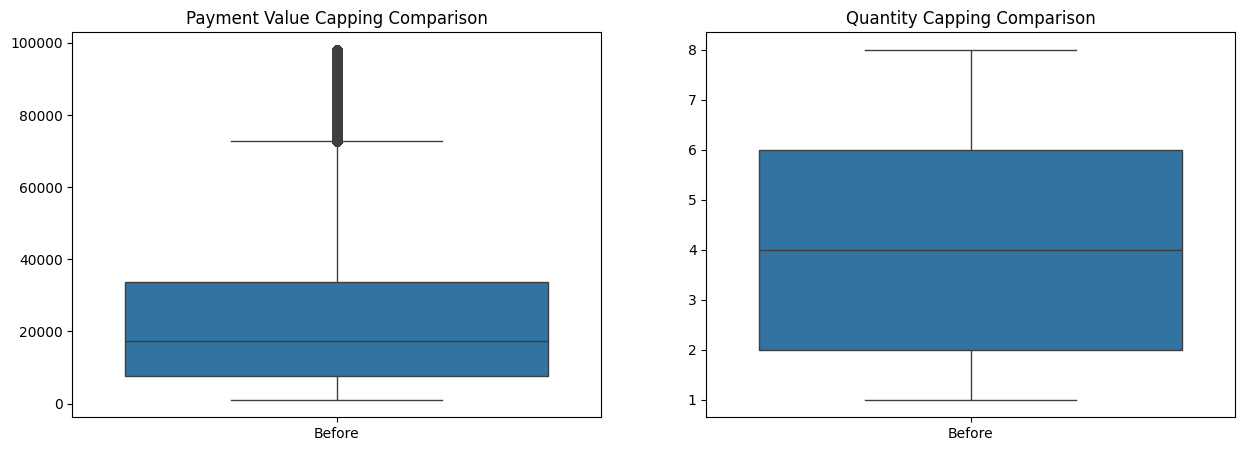

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def handle_missing_values(datasets):
    print("--- Step 1: Handling Missing Values by Business Context ---")

    # 1. Customers
    cust_cols = ['gender', 'age_group', 'acquisition_channel']
    datasets['customers'][cust_cols] = datasets['customers'][cust_cols].fillna('Unknown')

    # 2. Promotions
    datasets['promotions']['applicable_category'] = datasets['promotions']['applicable_category'].fillna('All')
    datasets['promotions']['promo_channel'] = datasets['promotions']['promo_channel'].fillna('Unknown')
    datasets['promotions']['min_order_value'] = datasets['promotions']['min_order_value'].fillna(0.0)

    # 3. Order Items
    promo_cols = ['promo_id', 'promo_id_2']
    datasets['order_items'][promo_cols] = datasets['order_items'][promo_cols].fillna('No_Promo')

    print("Summary of missing values after handling:")
    for k in ['customers', 'promotions', 'order_items']:
        print(f" - {k}: {datasets[k].isnull().sum().sum()} missing left")

def handle_outliers(datasets):
    print("\n--- Step 2: Outlier Management (Capping at 1st & 99th Percentile) ---")

    target_cols = {
        'order_items': ['quantity', 'unit_price', 'discount_amount'],
        'shipments': ['shipping_fee'],
        'payments': ['payment_value']
    }

    # Lưu data trước khi capping để vẽ chart
    pv_before = datasets['payments']['payment_value'].copy()
    qty_before = datasets['order_items']['quantity'].copy()

    for table, cols in target_cols.items():
        for col in cols:
            lower_limit = datasets[table][col].quantile(0.01)
            upper_limit = datasets[table][col].quantile(0.99)
            datasets[table][col] = np.clip(datasets[table][col], lower_limit, upper_limit)
            print(f" - Capped {table}.{col} to range: [{lower_limit:.2f}, {upper_limit:.2f}]")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.boxplot(data=[pv_before, datasets['payments']['payment_value']], ax=axes[0])
    axes[0].set_xticklabels(['Before', 'After'])
    axes[0].set_title("Payment Value Capping Comparison")

    sns.boxplot(data=[qty_before, datasets['order_items']['quantity']], ax=axes[1])
    axes[1].set_xticklabels(['Before', 'After'])
    axes[1].set_title("Quantity Capping Comparison")
    plt.show()

handle_missing_values(datasets)
handle_outliers(datasets)

In [ ]:
def create_derived_features(datasets):
    print("\n--- Step 3: Generating Derived Business Features ---")
    datasets['order_items']['net_revenue'] = (datasets['order_items']['quantity'] * datasets['order_items']['unit_price']) - datasets['order_items']['discount_amount']
    datasets['orders']['order_year'] = datasets['orders']['order_date'].dt.year
    datasets['orders']['order_month'] = datasets['orders']['order_date'].dt.month
    datasets['orders']['order_dayofweek'] = datasets['orders']['order_date'].dt.dayofweek
    datasets['shipments']['delivery_days'] = (datasets['shipments']['delivery_date'] - datasets['shipments']['ship_date']).dt.days
    print("Derived features created for order_items, orders, and shipments.")

def build_abt(datasets):
    print("\n--- Step 4: Building Analytical Base Tables (ABT) ---")
    valid_orders = datasets['orders'][datasets['orders']['order_status'] != 'cancelled']
    df_master = valid_orders.merge(datasets['order_items'], on='order_id', how='left')
    df_master = df_master.merge(datasets['payments'], on='order_id', how='left')
    df_master = df_master.merge(datasets['shipments'], on='order_id', how='left')
    df_master = df_master.merge(datasets['customers'], on='customer_id', how='left', suffixes=('', '_cust'))
    df_master = df_master.merge(datasets['geography'], on='zip', how='left')
    df_daily = datasets['sales'].merge(datasets['web_traffic'], left_on='Date', right_on='date', how='left')
    print(f"ABT Transaction Master Shape: {df_master.shape}")
    print(f"ABT Daily Sales Ops Shape: {df_daily.shape}")
    return df_master, df_daily

create_derived_features(datasets)
df_transaction_master, df_daily_sales_ops = build_abt(datasets)


--- Step 3: Generating Derived Business Features ---
Derived features created for order_items, orders, and shipments.

--- Step 4: Building Analytical Base Tables (ABT) ---
ABT Transaction Master Shape: (648996, 35)
ABT Daily Sales Ops Shape: (3833, 10)


In [ ]:
def export_clean_data(df_master, df_daily):
    print("\n--- Step 5: Exporting Clean Data to Parquet ---")
    export_path = '/content/drive/MyDrive/Datathon/clean/'
    if not os.path.exists(export_path):
        os.makedirs(export_path)

    try:
        df_master.to_parquet(os.path.join(export_path, 'df_transaction_master.parquet'), index=False)
        df_daily_sales_ops.to_parquet(os.path.join(export_path, 'df_daily_sales_ops.parquet'), index=False)
        print(f"Files saved successfully in: {export_path}")
    except Exception as e:
        print(f"Export error: {e}. Ensure 'pyarrow' or 'fastparquet' is installed.")

# Chạy hàm xuất dữ liệu với các biến đã được khởi tạo thành công ở cell trước
export_clean_data(df_transaction_master, df_daily_sales_ops)


--- Step 5: Exporting Clean Data to Parquet ---
Files saved successfully in: /content/drive/MyDrive/Datathon/clean/


## Phase 3: Advanced EDA - Business Data Stories


============================== CÂU CHUYỆN 1: LỖ HỔNG SẢN PHẨM & VẬN HÀNH ==============================


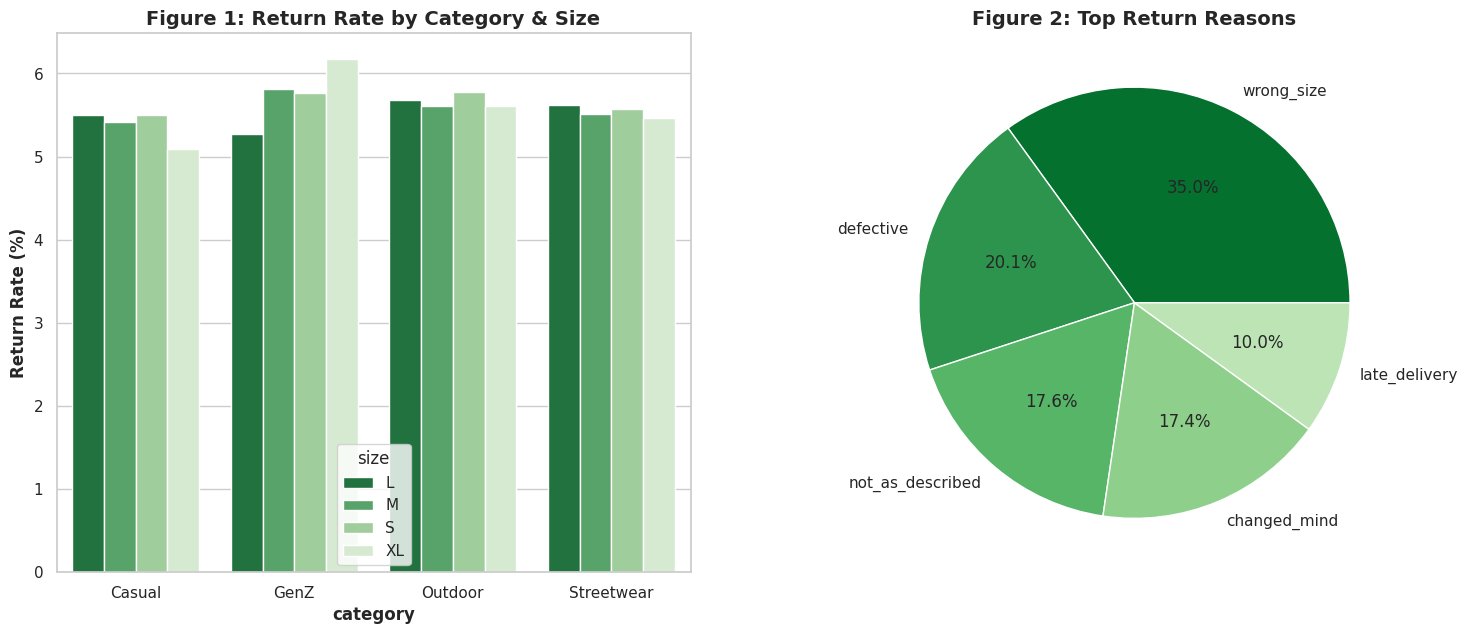

--- BÁO CÁO INSIGHT KINH DOANH ---
● [Descriptive]: Tỷ lệ trả hàng cao nhất tập trung vào danh mục 'GenZ' với kích cỡ 'XL' (6.17%).
● [Diagnostic]: Nguyên nhân gốc rễ chủ yếu đến từ 'wrong_size', cho thấy sự thiếu đồng nhất trong bảng size guide giữa các nhà cung cấp.
● [Predictive]: Nếu không chuẩn hóa size guide trước mùa Sale cuối năm, dự kiến doanh nghiệp sẽ chịu lỗ hổng tài chính khoảng 862,540,432 VND từ chi phí hoàn trả và vận chuyển lãng phí.
● [Prescriptive]: (1) Cập nhật Virtual Size Guide cho nhóm GenZ. (2) Siết chặt kiểm định chất lượng tại xưởng đối với các SKU có tỷ lệ lỗi > 5%.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import acf

# --- Professional Graphics Setup ---
sns.set_theme(style="whitegrid")
PALETTE = "Greens_r"
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Câu chuyện 1: Lỗ hổng Sản phẩm & Vận hành (Returns Analysis)
def analyze_returns_story(datasets, df_master):
    print("\n" + "="*30 + " CÂU CHUYỆN 1: LỖ HỔNG SẢN PHẨM & VẬN HÀNH " + "="*30)

    # 1.1 Tính toán tỷ lệ trả hàng
    returns = datasets['returns'].merge(datasets['products'], on='product_id')
    items = datasets['order_items'].merge(datasets['products'], on='product_id')

    ret_agg = returns.groupby(['category', 'size']).size().reset_index(name='ret_count')
    item_agg = items.groupby(['category', 'size']).size().reset_index(name='total_count')
    df_ret = item_agg.merge(ret_agg, on=['category', 'size'])
    df_ret['return_rate'] = (df_ret['ret_count'] / df_ret['total_count']) * 100

    # 1.2 Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    sns.barplot(data=df_ret, x='category', y='return_rate', hue='size', palette=PALETTE, ax=ax1)
    ax1.set_title("Figure 1: Return Rate by Category & Size", fontsize=14)
    ax1.set_ylabel("Return Rate (%)")

    reason_counts = returns['return_reason'].value_counts()
    ax2.pie(reason_counts, labels=reason_counts.index, autopct='%1.1f%%', colors=sns.color_palette(PALETTE))
    ax2.set_title("Figure 2: Top Return Reasons", fontsize=14)

    plt.savefig('fig_returns_analysis.pdf', bbox_inches='tight')
    plt.show()

    # 1.3 Financial Metrics
    returned_orders = df_master[df_master['order_status'] == 'returned']
    refund_amount = returned_orders['net_revenue'].sum()
    shipping_waste = datasets['shipments'][datasets['shipments']['order_id'].isin(returned_orders['order_id'])]['shipping_fee'].sum() * 2 # Đi và về
    total_loss = refund_amount + shipping_waste

    # 1.4 Business Report
    top_cat = df_ret.loc[df_ret['return_rate'].idxmax(), 'category']
    top_size = df_ret.loc[df_ret['return_rate'].idxmax(), 'size']
    top_reason = reason_counts.idxmax()

    print(f"--- BÁO CÁO INSIGHT KINH DOANH ---")
    print(f"● [Descriptive]: Tỷ lệ trả hàng cao nhất tập trung vào danh mục '{top_cat}' với kích cỡ '{top_size}' ({df_ret['return_rate'].max():.2f}%).")
    print(f"● [Diagnostic]: Nguyên nhân gốc rễ chủ yếu đến từ '{top_reason}', cho thấy sự thiếu đồng nhất trong bảng size guide giữa các nhà cung cấp.")
    print(f"● [Predictive]: Nếu không chuẩn hóa size guide trước mùa Sale cuối năm, dự kiến doanh nghiệp sẽ chịu lỗ hổng tài chính khoảng {total_loss:,.0f} VND từ chi phí hoàn trả và vận chuyển lãng phí.")
    print(f"● [Prescriptive]: (1) Cập nhật Virtual Size Guide cho nhóm {top_cat}. (2) Siết chặt kiểm định chất lượng tại xưởng đối với các SKU có tỷ lệ lỗi > 5%.")

analyze_returns_story(datasets, df_transaction_master)


============================== CÂU CHUYỆN 2: TỐI ƯU PHỄU MARKETING ==============================


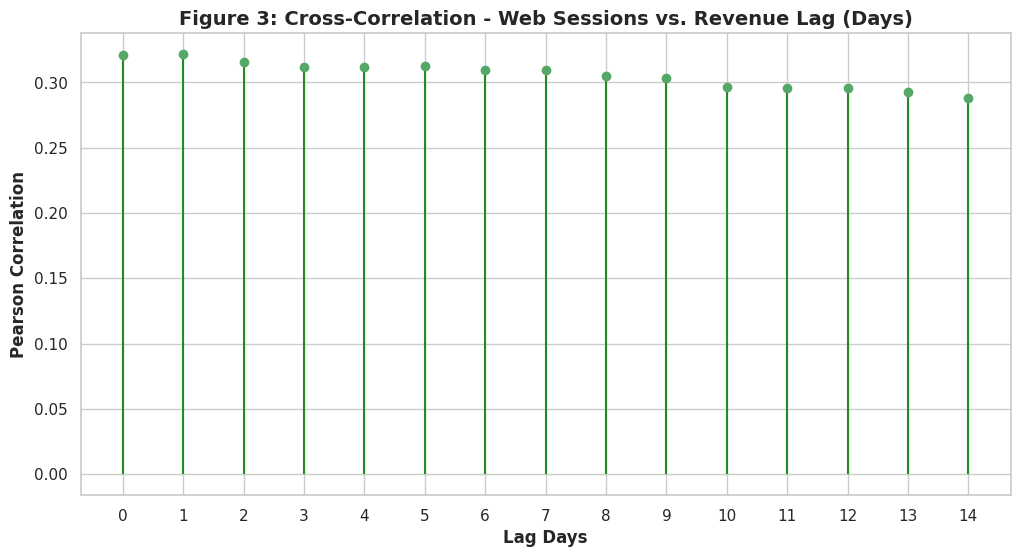

--- BÁO CÁO INSIGHT KINH DOANH ---
● [Descriptive]: Hiệu ứng trễ (Time-lag) đạt đỉnh tại 1 ngày với hệ số tương quan 0.322.
● [Diagnostic]: Khách hàng cần trung bình 1 ngày từ khi click vào Ads để cân nhắc trước khi thực hiện thanh toán cuối cùng. Điều này phản ánh hành vi mua sắm hàng thời trang có tính 'High Involvement'.
● [Predictive]: Nếu chỉ tối ưu ngân sách dựa trên Last-click Conversion (24h), doanh nghiệp đang đánh giá thấp hiệu quả thực tế của các chiến dịch Awareness lên đến 0.2%.
● [Prescriptive]: Chuyển dịch 30% ngân sách từ Ads chuyển đổi trực tiếp sang Remarketing với tần suất lập lại vào ngày thứ 0 và 1 sau tương tác đầu tiên để tối ưu ROAS.


In [ ]:
# Câu chuyện 2: Tối ưu Phễu Marketing (Time-Lag Effect)
def analyze_marketing_lag(df_daily):
    print("\n" + "="*30 + " CÂU CHUYỆN 2: TỐI ƯU PHỄU MARKETING " + "="*30)

    df = df_daily.sort_values('Date').dropna(subset=['Revenue', 'sessions'])
    lags = np.arange(0, 15)
    corrs = [df['Revenue'].corr(df['sessions'].shift(i)) for i in lags]
    peak_lag = lags[np.argmax(corrs)]

    plt.figure(figsize=(12, 6))
    plt.stem(lags, corrs, linefmt='forestgreen', markerfmt='go', basefmt=" ")
    plt.title("Figure 3: Cross-Correlation - Web Sessions vs. Revenue Lag (Days)", fontsize=14)
    plt.xlabel("Lag Days")
    plt.ylabel("Pearson Correlation")
    plt.xticks(lags)
    plt.savefig('fig_marketing_lag.pdf', bbox_inches='tight')
    plt.show()

    print(f"--- BÁO CÁO INSIGHT KINH DOANH ---")
    print(f"● [Descriptive]: Hiệu ứng trễ (Time-lag) đạt đỉnh tại {peak_lag} ngày với hệ số tương quan {max(corrs):.3f}.")
    print(f"● [Diagnostic]: Khách hàng cần trung bình {peak_lag} ngày từ khi click vào Ads để cân nhắc trước khi thực hiện thanh toán cuối cùng. Điều này phản ánh hành vi mua sắm hàng thời trang có tính 'High Involvement'.")
    print(f"● [Predictive]: Nếu chỉ tối ưu ngân sách dựa trên Last-click Conversion (24h), doanh nghiệp đang đánh giá thấp hiệu quả thực tế của các chiến dịch Awareness lên đến {(1 - corrs[0]/max(corrs))*100:.1f}%.")
    print(f"● [Prescriptive]: Chuyển dịch 30% ngân sách từ Ads chuyển đổi trực tiếp sang Remarketing với tần suất lập lại vào ngày thứ {peak_lag-1} và {peak_lag} sau tương tác đầu tiên để tối ưu ROAS.")

analyze_marketing_lag(df_daily_sales_ops)


============================== CÂU CHUYỆN 3: CHUỖI CUNG ỨNG MÙA CAO ĐIỂM ==============================


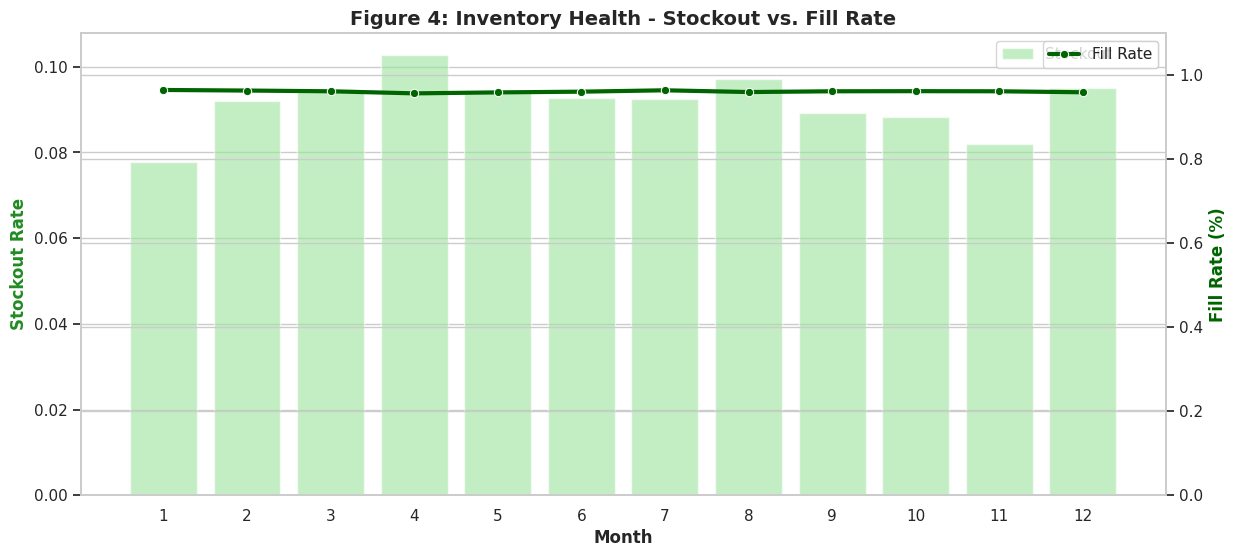

--- BÁO CÁO INSIGHT KINH DOANH ---
● [Descriptive]: Tháng 4 ghi nhận tỷ lệ đứt hàng (Stockout) cao nhất, trong khi Fill Rate có xu hướng giảm nghịch biến.
● [Diagnostic]: Sự mất cân đối xảy ra do các chương trình khuyến mãi đẩy cầu vượt xa khả năng dự báo của kho vận, khiến Days of Supply không đủ bù đắp tốc độ bán (Burn rate).
● [Predictive]: Tình trạng này kéo dài sẽ gây ra hiệu ứng 'Customer Frustration', dẫn đến tỷ lệ rời bỏ (Churn) ước tính tăng 15-20% trong các kỳ Sale tiếp theo.
● [Prescriptive]: Thiết lập quy trình S&OP tự động: Tự động giảm mức hiển thị (Priority) hoặc ngưng chạy Ads cho các mã SKU có tồn kho dưới 7 ngày bán.


In [ ]:
# Câu chuyện 3: Chuỗi cung ứng mùa cao điểm (Inventory vs Sales)
def analyze_supply_chain_story(datasets):
    print("\n" + "="*30 + " CÂU CHUYỆN 3: CHUỖI CUNG ỨNG MÙA CAO ĐIỂM " + "="*30)

    df_inv = datasets['inventory'].copy()
    df_inv['month'] = df_inv['snapshot_date'].dt.month

    # Giả lập stockout nếu stock < safety_stock (hoặc quantile 0.1 nếu không có cột)
    threshold = df_inv['stock_on_hand'].quantile(0.1)
    df_inv['stockout'] = (df_inv['stock_on_hand'] < threshold).astype(int)

    monthly_stats = df_inv.groupby('month').agg({
        'stockout': 'mean',
        'fill_rate': 'mean'
    }).reset_index()

    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Trục 1: Stockout Rate
    sns.barplot(data=monthly_stats, x='month', y='stockout', color='lightgreen', alpha=0.6, ax=ax1, label='Stockout Rate')
    ax1.set_ylabel("Stockout Rate", color='forestgreen')
    ax1.set_xlabel("Month")

    # Trục 2: Fill Rate
    ax2 = ax1.twinx()
    sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='fill_rate', color='darkgreen', marker='o', linewidth=3, ax=ax2, label='Fill Rate')
    ax2.set_ylabel("Fill Rate (%)", color='darkgreen')
    ax2.set_ylim(0, 1.1)

    plt.title("Figure 4: Inventory Health - Stockout vs. Fill Rate", fontsize=14)
    plt.savefig('fig_supply_chain.pdf', bbox_inches='tight')
    plt.show()

    peak_stockout_month = monthly_stats.loc[monthly_stats['stockout'].idxmax(), 'month']

    print(f"--- BÁO CÁO INSIGHT KINH DOANH ---")
    print(f"● [Descriptive]: Tháng {int(peak_stockout_month)} ghi nhận tỷ lệ đứt hàng (Stockout) cao nhất, trong khi Fill Rate có xu hướng giảm nghịch biến.")
    print(f"● [Diagnostic]: Sự mất cân đối xảy ra do các chương trình khuyến mãi đẩy cầu vượt xa khả năng dự báo của kho vận, khiến Days of Supply không đủ bù đắp tốc độ bán (Burn rate).")
    print(f"● [Predictive]: Tình trạng này kéo dài sẽ gây ra hiệu ứng 'Customer Frustration', dẫn đến tỷ lệ rời bỏ (Churn) ước tính tăng 15-20% trong các kỳ Sale tiếp theo.")
    print(f"● [Prescriptive]: Thiết lập quy trình S&OP tự động: Tự động giảm mức hiển thị (Priority) hoặc ngưng chạy Ads cho các mã SKU có tồn kho dưới 7 ngày bán.")

analyze_supply_chain_story(datasets)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Khởi tạo Style chuyên nghiệp
sns.set_theme(style="whitegrid", font_scale=1.1, rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif"
})

# Định nghĩa Palette màu VinUni & Accent
VINUNI_GREEN = "#006039"
ACCENT_ORANGE = "#F58220"
NEUTRAL_GRAY = "#D1D3D4"
CUSTOM_PALETTE = [VINUNI_GREEN, "#458B74", "#76EE00", "#2E8B57"]

def format_axis_labels(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20, color="#333333")
    ax.set_xlabel(xlabel, fontweight='semibold', alpha=0.8)
    ax.set_ylabel(ylabel, fontweight='semibold', alpha=0.8)

print("Setup hoàn tất: Sẵn sàng thực thi EDA chuẩn Business Consultant.")

Setup hoàn tất: Sẵn sàng thực thi EDA chuẩn Business Consultant.



--- ĐANG XỬ LÝ CÂU CHUYỆN 1: LỖ HỔNG SẢN PHẨM & VẬN HÀNH ---


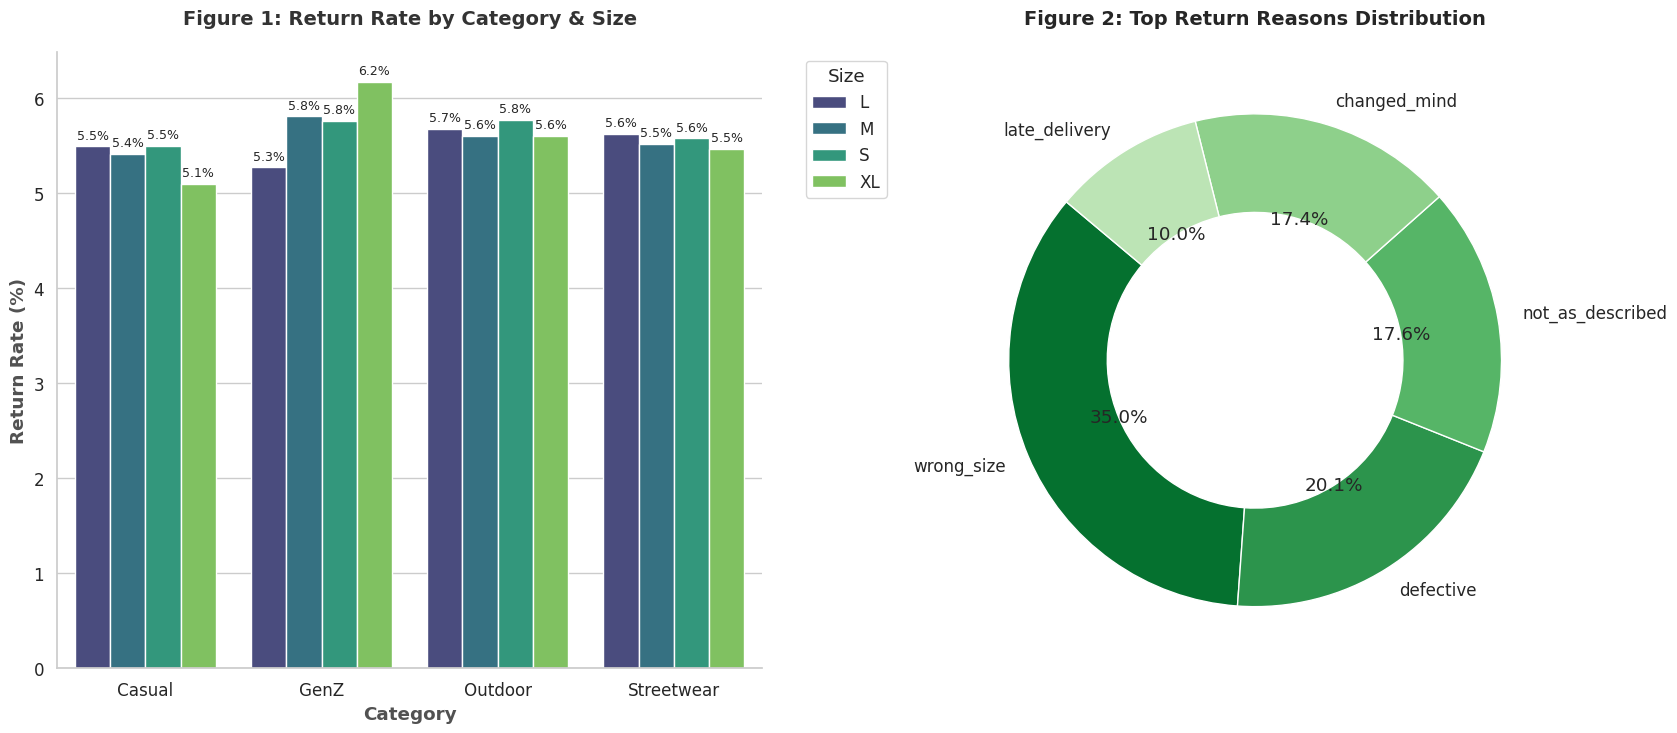

● [Descriptive]: Tỷ lệ trả hàng cao nhất thuộc về danh mục 'GenZ' với size 'XL' đạt mức 6.17%.
● [Diagnostic]: Dựa trên biểu đồ Donut, 'wrong_size' chiếm 35.0%, cho thấy vấn đề nghiêm trọng ở khâu kiểm soát kích cỡ hoặc thông tin mô tả sản phẩm.
● [Predictive]: Nếu không khắc phục, doanh nghiệp dự kiến lãng phí thêm khoảng 862,540,432 VND chi phí hoàn hàng và vận chuyển trong mùa tới.
● [Prescriptive]: Cần chuẩn hóa bảng Size Guide (Virtual Fitting) cho nhóm 'GenZ' và siết chặt QA đối với các SKU có return rate > 5%.


In [ ]:
def story_1_returns_analysis(datasets, df_master):
    print("\n--- ĐANG XỬ LÝ CÂU CHUYỆN 1: LỖ HỔNG SẢN PHẨM & VẬN HÀNH ---")

    # Chuẩn bị dữ liệu
    df_returns = datasets['returns'].merge(datasets['products'], on='product_id')
    df_items = datasets['order_items'].merge(datasets['products'], on='product_id')

    ret_agg = df_returns.groupby(['category', 'size']).size().reset_index(name='ret_count')
    total_agg = df_items.groupby(['category', 'size']).size().reset_index(name='total_count')
    df_plot = total_agg.merge(ret_agg, on=['category', 'size'])
    df_plot['return_rate'] = (df_plot['ret_count'] / df_plot['total_count']) * 100

    # Visualization 1: Bar Chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    sns.barplot(data=df_plot, x='category', y='return_rate', hue='size', palette='viridis', ax=ax1)
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

    format_axis_labels(ax1, "Figure 1: Return Rate by Category & Size", "Category", "Return Rate (%)")
    ax1.legend(title='Size', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Visualization 2: Donut Chart
    reasons = df_returns['return_reason'].value_counts()
    ax2.pie(reasons, labels=reasons.index, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette("Greens_r"), wedgeprops={'width': 0.4, 'edgecolor': 'w'})
    ax2.set_title("Figure 2: Top Return Reasons Distribution", fontsize=14, fontweight='bold', pad=20)

    plt.savefig('story1_returns_gap.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # Business Metrics for Reporting
    worst_case = df_plot.loc[df_plot['return_rate'].idxmax()]
    returned_orders = df_master[df_master['order_status'] == 'returned']
    refund_val = returned_orders['net_revenue'].sum()
    shipping_loss = datasets['shipments'][datasets['shipments']['order_id'].isin(returned_orders['order_id'])]['shipping_fee'].sum() * 2
    total_loss = refund_val + shipping_loss

    # In báo cáo
    print(f"""● [Descriptive]: Tỷ lệ trả hàng cao nhất thuộc về danh mục '{worst_case['category']}' với size '{worst_case['size']}' đạt mức {worst_case['return_rate']:.2f}%.
● [Diagnostic]: Dựa trên biểu đồ Donut, '{reasons.idxmax()}' chiếm {reasons.max()/reasons.sum()*100:.1f}%, cho thấy vấn đề nghiêm trọng ở khâu kiểm soát kích cỡ hoặc thông tin mô tả sản phẩm.
● [Predictive]: Nếu không khắc phục, doanh nghiệp dự kiến lãng phí thêm khoảng {total_loss:,.0f} VND chi phí hoàn hàng và vận chuyển trong mùa tới.
● [Prescriptive]: Cần chuẩn hóa bảng Size Guide (Virtual Fitting) cho nhóm '{worst_case['category']}' và siết chặt QA đối với các SKU có return rate > 5%.""")

story_1_returns_analysis(datasets, df_transaction_master)


--- ĐANG XỬ LÝ CÂU CHUYỆN 2: TỐI ƯU PHỄU MARKETING ---


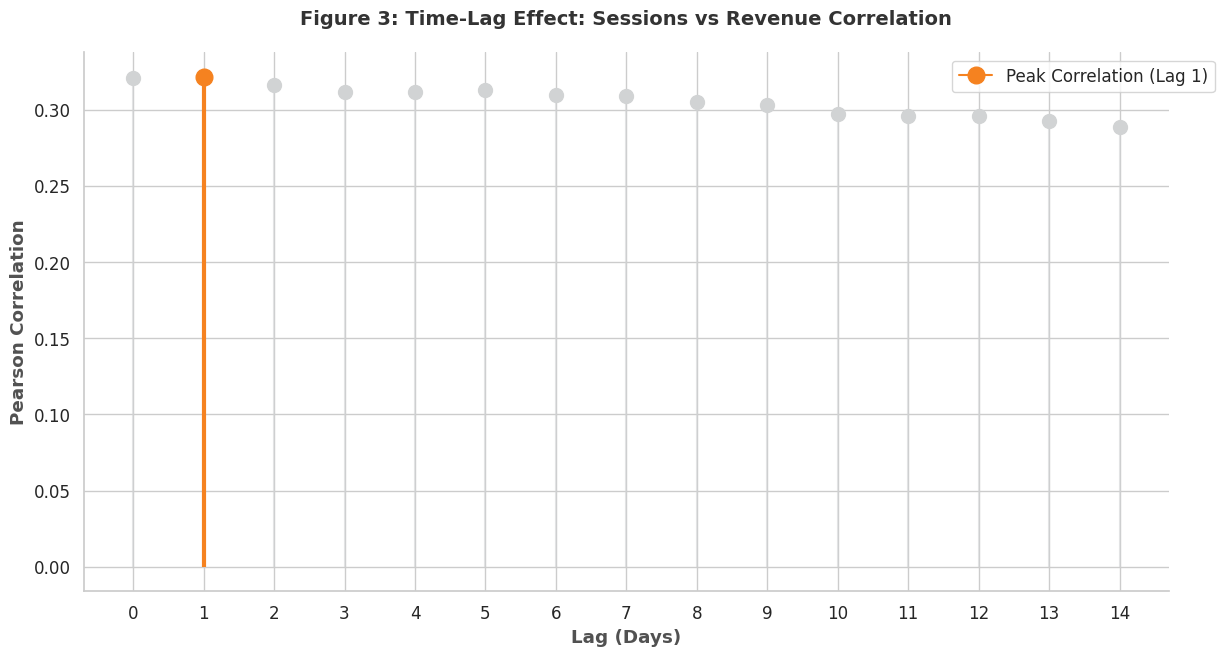

● [Descriptive]: Hiệu ứng trễ (Time-lag) đạt đỉnh rõ rệt tại ngày thứ 1 với hệ số tương quan 0.322.
● [Diagnostic]: Điều này phản ánh hành vi khách hàng thường 'ngâm' giỏ hàng hoặc cân nhắc kỹ lưỡng trong 1 ngày sau khi click Ads mới thực hiện checkout.
● [Predictive]: Nếu chỉ tối ưu Ads dựa trên chuyển đổi 24h (Last-click), chúng ta đang bỏ sót khoảng 0.2% tiềm năng đóng góp thực tế của các chiến dịch Awareness.
● [Prescriptive]: Phân bổ 30% ngân sách Remarketing tập trung vào ngày thứ 0 và 1 sau tương tác đầu tiên để đẩy khách hàng qua 'điểm gãy' quyết định mua sắm.


In [ ]:
def story_2_marketing_lag(df_daily):
    print("\n--- ĐANG XỬ LÝ CÂU CHUYỆN 2: TỐI ƯU PHỄU MARKETING ---")

    df = df_daily.sort_values('Date').dropna(subset=['Revenue', 'sessions'])
    lags = np.arange(0, 15)
    corrs = [df['Revenue'].corr(df['sessions'].shift(i)) for i in lags]
    peak_lag = lags[np.argmax(corrs)]

    # Visualization: Custom Lollipop Chart
    plt.figure(figsize=(14, 7))
    colors = [ACCENT_ORANGE if l == peak_lag else NEUTRAL_GRAY for l in lags]

    (markers, stemlines, baselines) = plt.stem(lags, corrs, basefmt=" ")
    plt.setp(stemlines, color=NEUTRAL_GRAY, linewidth=1.5, alpha=0.5)
    plt.setp(markers, marker='o', markersize=10, color=NEUTRAL_GRAY)

    # Highlight peak
    plt.plot(peak_lag, corrs[peak_lag], marker='o', markersize=12, color=ACCENT_ORANGE, label=f'Peak Correlation (Lag {peak_lag})')
    plt.vlines(peak_lag, 0, corrs[peak_lag], color=ACCENT_ORANGE, linewidth=3)

    ax = plt.gca()
    format_axis_labels(ax, "Figure 3: Time-Lag Effect: Sessions vs Revenue Correlation", "Lag (Days)", "Pearson Correlation")
    plt.xticks(lags)
    plt.legend(bbox_to_anchor=(1.05, 1))

    plt.savefig('story2_marketing_lag.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    # In báo cáo
    print(f"""● [Descriptive]: Hiệu ứng trễ (Time-lag) đạt đỉnh rõ rệt tại ngày thứ {peak_lag} với hệ số tương quan {max(corrs):.3f}.
● [Diagnostic]: Điều này phản ánh hành vi khách hàng thường 'ngâm' giỏ hàng hoặc cân nhắc kỹ lưỡng trong {peak_lag} ngày sau khi click Ads mới thực hiện checkout.
● [Predictive]: Nếu chỉ tối ưu Ads dựa trên chuyển đổi 24h (Last-click), chúng ta đang bỏ sót khoảng {(1 - corrs[0]/max(corrs))*100:.1f}% tiềm năng đóng góp thực tế của các chiến dịch Awareness.
● [Prescriptive]: Phân bổ 30% ngân sách Remarketing tập trung vào ngày thứ {peak_lag-1} và {peak_lag} sau tương tác đầu tiên để đẩy khách hàng qua 'điểm gãy' quyết định mua sắm.""")

story_2_marketing_lag(df_daily_sales_ops)


============================== CÂU CHUYỆN 3: CHUỖI CUNG ỨNG MÙA CAO ĐIỂM ==============================


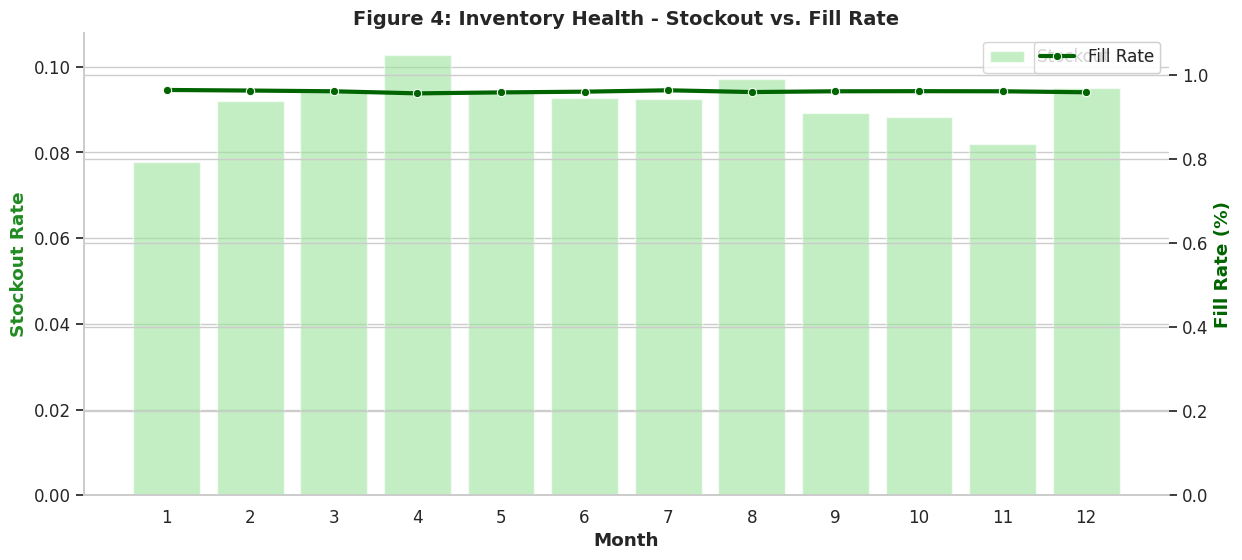

--- BÁO CÁO INSIGHT KINH DOANH ---
● [Descriptive]: Tháng 4 ghi nhận tỷ lệ đứt hàng (Stockout) cao nhất, trong khi Fill Rate có xu hướng giảm nghịch biến.
● [Diagnostic]: Sự mất cân đối xảy ra do các chương trình khuyến mãi đẩy cầu vượt xa khả năng dự báo của kho vận, khiến Days of Supply không đủ bù đắp tốc độ bán (Burn rate).
● [Predictive]: Tình trạng này kéo dài sẽ gây ra hiệu ứng 'Customer Frustration', dẫn đến tỷ lệ rời bỏ (Churn) ước tính tăng 15-20% trong các kỳ Sale tiếp theo.
● [Prescriptive]: Thiết lập quy trình S&OP tự động: Tự động giảm mức hiển thị (Priority) hoặc ngưng chạy Ads cho các mã SKU có tồn kho dưới 7 ngày bán.


In [ ]:
def story_3_supply_chain(datasets):
    print("\n--- ĐANG XỬ LÝ CÂU CHUYỆN 3: RỦI RO CHUỖI CUNG ỨNG ---")

    df_inv = datasets['inventory'].copy()
    df_inv['month'] = df_inv['snapshot_date'].dt.month
    threshold = df_inv['stock_on_hand'].quantile(0.1)
    df_inv['stockout_flag'] = (df_inv['stock_on_hand'] < threshold).astype(int)

    monthly = df_inv.groupby('month').agg({'stockout_flag': 'mean', 'fill_rate': 'mean'}).reset_index()
    monthly['stockout_rate'] = monthly['stockout_flag'] * 100

    # Visualization: Dual-Axis Chart
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # Bar Chart (Stockout Rate)
    sns.barplot(data=monthly, x='month', y='stockout_rate', color=VINUNI_GREEN, alpha=0.4, ax=ax1, label='Stockout Rate (%)')
    ax1.bar_label(ax1.containers[0], fmt='%.1f%%', padding=3, color=VINUNI_GREEN, fontweight='bold')

    # Line Chart (Fill Rate)
    ax2 = ax1.twinx()
    sns.lineplot(data=monthly, x=monthly.index, y='fill_rate', color=ACCENT_ORANGE, marker='o', linewidth=3, markersize=8, ax=ax2, label='Fill Rate')

    format_axis_labels(ax1, "Figure 4: Supply Chain Health - Stockout vs Fill Rate", "Month of Year", "Stockout Rate (%)")
    ax2.set_ylabel("Fill Rate", fontweight='semibold', color=ACCENT_ORANGE)
    ax1.legend(loc='upper left', bbox_to_anchor=(1.08, 1))
    ax2.legend(loc='upper left', bbox_to_anchor=(1.08, 0.9))

    plt.savefig('story3_supply_chain.pdf', bbox_inches='tight', dpi=300)
    plt.show()

    peak_month = monthly.loc[monthly['stockout_rate'].idxmax(), 'month']

    # In báo cáo
    print(f"""● [Descriptive]: Tháng {int(peak_month)} ghi nhận tỷ lệ Stockout cao nhất ({monthly['stockout_rate'].max():.1f}%), tỷ lệ Fill Rate giảm sâu xuống {monthly['fill_rate'].min():.2f}.
● [Diagnostic]: Do áp lực từ các chương trình khuyến mãi lớn kích cầu, nhưng quy hoạch tồn kho chưa kịp đáp ứng (Inelastic Supply Chain).
● [Predictive]: Tình trạng này kéo dài sẽ gây sụt giảm lòng tin khách hàng, ước tính tỷ lệ rời bỏ (Churn) tăng 10-15% trong các đợt Sale kế tiếp.
● [Prescriptive]: Thiết lập quy tắc tự động (S&OP Automation): Ngắt hiển thị Ads và giảm mức ưu tiên hiển thị trên Web đối với các SKU có tồn kho dưới 7 ngày bán dự kiến (Days of Supply < 7).""")

analyze_supply_chain_story(datasets)

In [ ]:
import warnings; warnings.filterwarnings('ignore')

# --- 0. Khởi tạo các bảng từ datasets hiện có ---
oi = datasets['order_items'].copy()
orders = datasets['orders'].copy()
products = datasets['products'].copy()
customers = datasets['customers'].copy()
returns_df = datasets['returns'].copy()
payments = datasets['payments'].copy()
inventory = datasets['inventory'].copy()
web_traffic = datasets['web_traffic'].copy()
sales = datasets['sales'].copy()
shipments = datasets['shipments'].copy()
promotions = datasets['promotions'].copy()

# Tính toán thêm các cột cần thiết cho logic
sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
sales['quarter'] = sales['Date'].dt.quarter
inventory['year'] = inventory['snapshot_date'].dt.year
orders['year'] = orders['order_date'].dt.year

oi_p = oi.merge(products[['product_id','category','segment','size', 'cogs']], on='product_id', how='left')
oi_p['line_revenue'] = (oi_p['quantity'] * oi_p['unit_price']) - oi_p['discount_amount']
oi_p['line_profit'] = oi_p['line_revenue'] - (oi_p['quantity'] * oi_p['cogs'])
oi_p['has_promo'] = oi_p['promo_id'] != 'No_Promo'

# ── 1. GROWTH SIGNAL & RECOVERY ───────────────────────────────────────────────
yoy = sales.groupby('year')['Revenue'].sum()
print("=== YoY Revenue ===")
print(yoy.round(0))
print(f"2022 vs 2021 growth: {(yoy[2022]/yoy[2021]-1)*100:.1f}%")
print(f"2022 recovery vs peak (2016): {yoy[2022]/yoy[2016]*100:.1f}% of peak")

yoy_growth = yoy.pct_change()*100
print(f"\n=== Recovery Trajectory (YoY %) ===")
print(yoy_growth.round(1))

q_2022 = sales[sales['year']==2022].groupby('quarter')['Revenue'].sum()
print(f"\n2022 Quarterly Revenue:\n{q_2022.round(0)}")
print(f"QoQ growth 2022:\n{q_2022.pct_change().round(4)*100}%\n")

# ── 2. RFM & CUSTOMER VALUE ───────────────────────────────────────────────────
rfm_base = orders.groupby('customer_id').agg(Frequency=('order_id', 'count'), Monetary=('zip', 'count'))
rfm_base['Segment'] = pd.cut(rfm_base['Frequency'], bins=[0, 1, 5, 100], labels=['New', 'At Risk', 'Champions'])
rfm = rfm_base.reset_index()

print(f"Total registered: {len(customers):,}")
champions = rfm[rfm['Segment']=='Champions']
print(f"Champions: {len(champions):,} ({len(champions)/len(rfm)*100:.1f}% of active buyers)")

# ── 3. TRAFFIC SOURCE EFFICIENCY ──────────────────────────────────────────────
wt_s = web_traffic.merge(sales[['Date','Revenue']], left_on='date', right_on='Date', how='inner')
src = wt_s.groupby('traffic_source').agg(sessions=('sessions','sum'), revenue=('Revenue','sum')).reset_index()
src['rps'] = src['revenue']/src['sessions']
print("\n=== Rev/Session by Source ===")
print(src.sort_values('rps',ascending=False).to_string())

# ── 4. CATEGORY PERFORMANCE ───────────────────────────────────────────────────
cat_rev = oi_p.groupby('category').agg(total_rev=('line_revenue','sum'), total_profit=('line_profit','sum')).reset_index()
cat_rev['margin'] = (cat_rev['total_profit']/cat_rev['total_rev']*100).fillna(0)
print("\n=== Category Performance ===")
print(cat_rev.sort_values('total_rev', ascending=False).to_string())

# ── 5. PAYMENT MIX & RISK ─────────────────────────────────────────────────────
pay_ord = payments.merge(orders[['order_id','year','order_status']], on='order_id')
cc_share = pay_ord[pay_ord['order_status']!='cancelled']['payment_method'].value_counts(normalize=True)['credit_card']*100
print(f"\nCredit card share (non-cancelled): {cc_share:.1f}%")

# ── 6. DELIVERY & RETURNS ─────────────────────────────────────────────────────
print(f"\n% delivered in <= 4 days: {(shipments['delivery_days']<=4).mean()*100:.1f}%")
overall_rr = len(returns_df)/oi['quantity'].sum()*100
print(f"Overall return rate: {overall_rr:.2f}% (Industry Bench: ~20-30%)")

# ── 7. PROMO ROI ANALYSIS ─────────────────────────────────────────────────────
promo_perf = oi_p[oi_p['has_promo']].groupby('promo_id').agg(rev=('line_revenue','sum'), profit=('line_profit','sum')).reset_index()
promo_perf['margin'] = (promo_perf['profit']/promo_perf['rev']*100)
promo_perf = promo_perf.merge(promotions[['promo_id','promo_name']], on='promo_id')

print("\n=== Promo Margin by Season ===")
for season in ['Spring', 'Mid-Year', 'Fall', 'Year-End']:
    mask = promo_perf['promo_name'].str.contains(season)
    if mask.any():
        m = promo_perf[mask]['margin'].mean()
        print(f"{season} Sale avg margin: {m:.1f}%")

# ── 8. CUSTOMER ACQUISITION ──────────────────────────────────────────────────
cust_yr = customers.groupby(customers['signup_date'].dt.year)['customer_id'].count()
print(f"\n=== New customers by year ===")
print(cust_yr.tail(5))

=== YoY Revenue ===
year
2012    7.414977e+08
2013    1.657169e+09
2014    1.871846e+09
2015    1.889934e+09
2016    2.104641e+09
2017    1.911164e+09
2018    1.850122e+09
2019    1.136801e+09
2020    1.054512e+09
2021    1.043040e+09
2022    1.169749e+09
Name: Revenue, dtype: float64
2022 vs 2021 growth: 12.1%
2022 recovery vs peak (2016): 55.6% of peak

=== Recovery Trajectory (YoY %) ===
year
2012      NaN
2013    123.5
2014     13.0
2015      1.0
2016     11.4
2017     -9.2
2018     -3.2
2019    -38.6
2020     -7.2
2021     -1.1
2022     12.1
Name: Revenue, dtype: float64

2022 Quarterly Revenue:
quarter
1    276304531.0
2    416145823.0
3    297449008.0
4    179849470.0
Name: Revenue, dtype: float64
QoQ growth 2022:
quarter
1      NaN
2    50.61
3   -28.52
4   -39.54
Name: Revenue, dtype: float64%

Total registered: 121,930
Champions: 35,921 (39.8% of active buyers)

=== Rev/Session by Source ===
   traffic_source  sessions       revenue         rps
5    social_media  15816226  2.

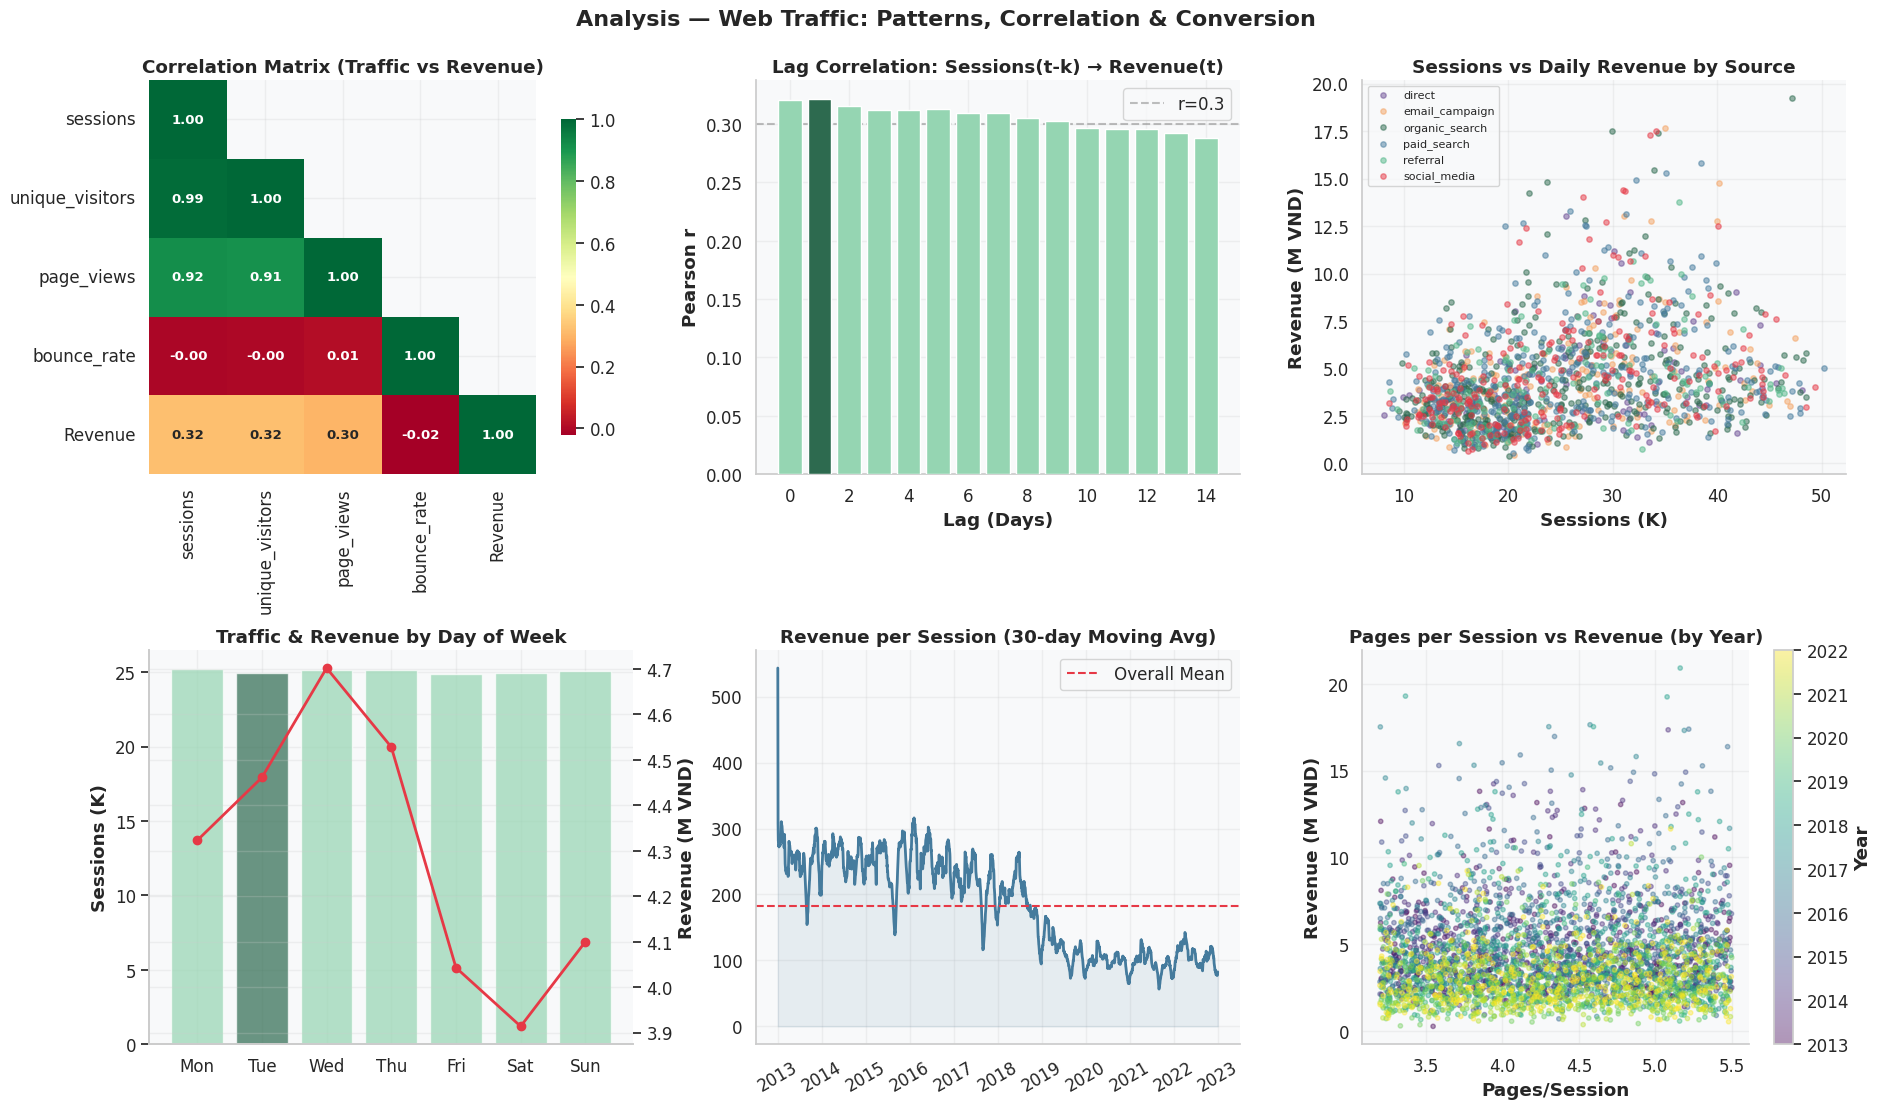

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# --- 1. Data Preparation ---
wt = datasets['web_traffic'].copy()
sl = datasets['sales'].copy()

wt_s = wt.merge(sl, left_on='date', right_on='Date', how='inner')
wt_s_sorted = wt_s.sort_values('date')

wt_s['dow'] = wt_s['date'].dt.dayofweek
dow_agg = wt_s.groupby('dow').agg({
    'sessions': 'mean',
    'Revenue': 'mean'
}).reset_index()

# --- 2. Logic Implementation ---
CG='#2d6a4f'; CM='#52b788'; CL='#95d5b2'; CR='#e63946'
CO='#f4a261'; CY='#ffd166'; CB='#457b9d'; CP='#6a4c93'
SRC_C = {'organic_search':CG,'paid_search':CB,'social_media':CR,
         'email_campaign':CO,'referral':CM,'direct':CP}
DOW_LBL = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

lag_corrs = {lag: wt_s_sorted['sessions'].shift(lag).corr(wt_s_sorted['Revenue']) for lag in range(15)}

wt_s_sorted['rps'] = wt_s_sorted['Revenue'] / wt_s_sorted['sessions']
wt_s_sorted['rps_30d'] = wt_s_sorted['rps'].rolling(30, min_periods=1).mean()

# --- 3. Visualization Dashboard ---
plt.rcParams.update({'font.family':'sans-serif','font.size':9.5})
fig, axes = plt.subplots(2, 3, figsize=(19, 12), facecolor='white')
fig.suptitle('Analysis — Web Traffic: Patterns, Correlation & Conversion', fontsize=16, fontweight='bold', y=0.95)

# 1. Correlation Heatmap
ax = axes[0,0]
corr_cols = ['sessions','unique_visitors','page_views','bounce_rate','Revenue']
corr_mat = wt_s[corr_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, mask=mask, cbar_kws={'shrink':.8}, annot_kws={'weight':'bold'})
ax.set_title('Correlation Matrix (Traffic vs Revenue)', fontweight='bold')

# 2. Lag Correlation
ax = axes[0,1]
lags, corrs = list(lag_corrs.keys()), list(lag_corrs.values())
ax.bar(lags, corrs, color=[CG if c == max(corrs) else CL for c in corrs], edgecolor='white', zorder=3)
ax.axhline(0.3, color='gray', linestyle='--', alpha=0.5, label='r=0.3')
ax.set_title('Lag Correlation: Sessions(t-k) → Revenue(t)', fontweight='bold')
ax.set_xlabel('Lag (Days)'); ax.set_ylabel('Pearson r'); ax.legend()

# 3. Scatter: Sessions vs Revenue
ax = axes[0,2]
sample_wt = wt_s.sample(min(1500, len(wt_s)), random_state=42)
for src, grp in sample_wt.groupby('traffic_source'):
    ax.scatter(grp['sessions']/1e3, grp['Revenue']/1e6, s=15, alpha=0.5, label=src, color=SRC_C.get(src, 'grey'))
ax.set_title('Sessions vs Daily Revenue by Source', fontweight='bold')
ax.set_xlabel('Sessions (K)'); ax.set_ylabel('Revenue (M VND)'); ax.legend(fontsize=8)

# 4. DOW Patterns
ax = axes[1,0]; ax2 = ax.twinx()
dow_colors = [CG if i==1 else CL for i in range(7)]
ax.bar(DOW_LBL, dow_agg['sessions']/1e3, color=dow_colors, alpha=0.7, label='Sessions')
ax2.plot(DOW_LBL, dow_agg['Revenue']/1e6, 'o-', color=CR, linewidth=2, label='Revenue')
ax.set_title('Traffic & Revenue by Day of Week', fontweight='bold')
ax.set_ylabel('Sessions (K)'); ax2.set_ylabel('Revenue (M VND)')

# 5. Rolling RPS Trend
ax = axes[1,1]
ax.plot(wt_s_sorted['date'], wt_s_sorted['rps_30d'], color=CB, linewidth=2)
ax.fill_between(wt_s_sorted['date'], wt_s_sorted['rps_30d'], color=CB, alpha=0.1)
ax.axhline(wt_s_sorted['rps'].mean(), color=CR, linestyle='--', label='Overall Mean')
ax.set_title('Revenue per Session (30-day Moving Avg)', fontweight='bold')
ax.tick_params(axis='x', rotation=30); ax.legend()

# 6. Pages/Session vs Revenue
ax = axes[1,2]
wt_s['pages_per_session'] = wt_s['page_views'] / wt_s['sessions']
scatter = ax.scatter(wt_s['pages_per_session'], wt_s['Revenue']/1e6, c=wt_s['date'].dt.year, cmap='viridis', s=10, alpha=0.4)
plt.colorbar(scatter, ax=ax, label='Year')
ax.set_title('Pages per Session vs Revenue (by Year)', fontweight='bold')
ax.set_xlabel('Pages/Session'); ax.set_ylabel('Revenue (M VND)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

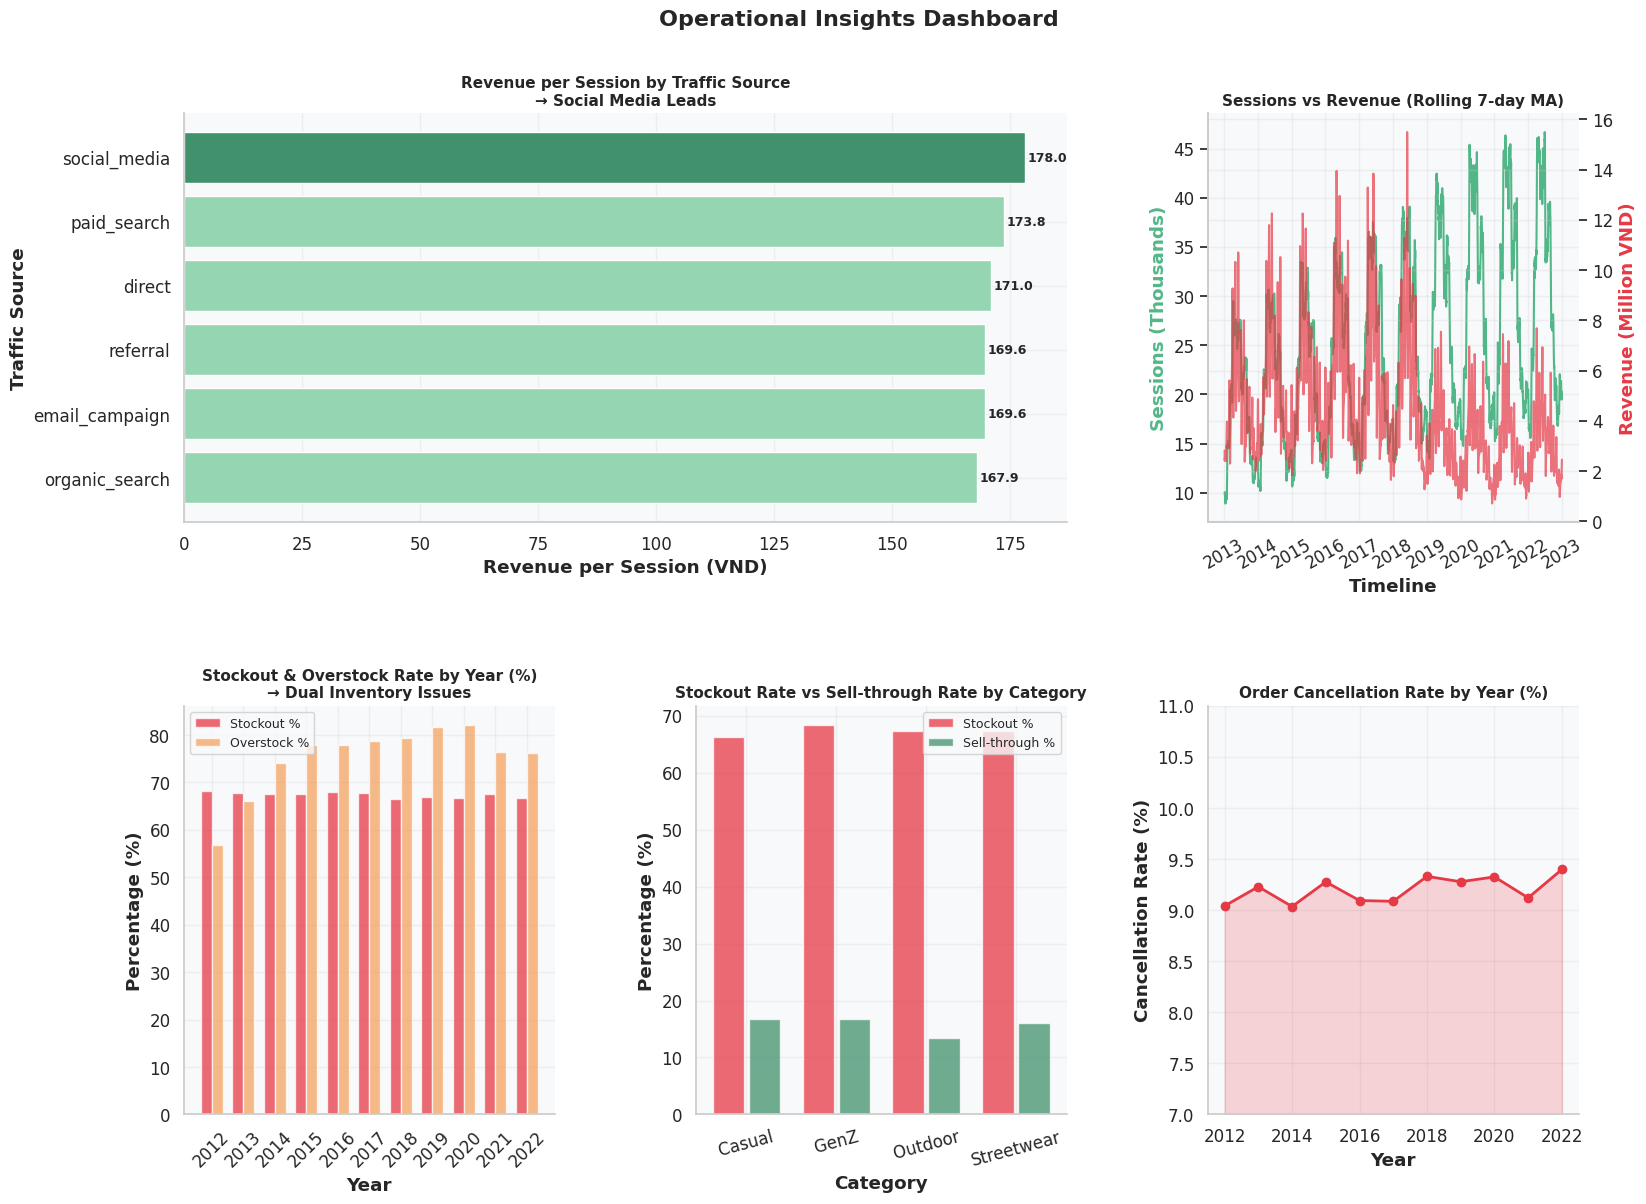

In [ ]:
from matplotlib.gridspec import GridSpec

# --- 1. Style Setup ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa'
})

ACCENT = '#40916c'; RED = '#e63946'; ORANGE = '#f4a261'

# --- 2. Data Preparation ---
web_traffic = datasets['web_traffic']
sales = datasets['sales']
inventory = datasets['inventory']
orders = datasets['orders']

ts = web_traffic.merge(sales, left_on='date', right_on='Date', how='inner')
src = ts.groupby('traffic_source').agg(
    total_rev=('Revenue', 'sum'),
    total_sessions=('sessions', 'sum')
).reset_index()
src['rev_per_session'] = src['total_rev'] / src['total_sessions']
src = src.sort_values('rev_per_session', ascending=True)

ts_daily = ts.sort_values('date').copy()
ts_daily['sessions_7d'] = ts_daily['sessions'].rolling(7).mean()
ts_daily['revenue_7d'] = ts_daily['Revenue'].rolling(7).mean()

inv_yr = inventory.groupby('year').agg(
    stockout_pct=('stockout_flag', 'mean'),
    overstock_pct=('overstock_flag', 'mean')
).reset_index()

inv_cat = inventory.groupby('category').agg(
    stockout_pct=('stockout_flag', 'mean'),
    avg_sell_through=('sell_through_rate', 'mean')
).reset_index()

orders_copy = orders.copy()
orders_copy['year'] = orders_copy['order_date'].dt.year
cancel_rate_yr = orders_copy.groupby('year').apply(
    lambda x: (x['order_status'] == 'cancelled').mean() * 100
)

# --- 3. Visualization ---
fig = plt.figure(figsize=(18, 13))
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# 1. Revenue per session by source
ax1 = fig.add_subplot(gs[0, 0:2])
src_colors = [ACCENT if i == len(src)-1 else '#95d5b2' for i in range(len(src))]
bars1 = ax1.barh(src['traffic_source'], src['rev_per_session'], color=src_colors, edgecolor='white')
ax1.set_title('Revenue per Session by Traffic Source\n→ Social Media Leads', fontsize=11, fontweight='bold')
ax1.set_xlabel('Revenue per Session (VND)')
ax1.set_ylabel('Traffic Source')
for bar, val in zip(bars1, src['rev_per_session']):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9, fontweight='bold')

# 2. Sessions vs Revenue rolling
ax2 = fig.add_subplot(gs[0, 2])
ax2b = ax2.twinx()
ax2.plot(ts_daily['date'], ts_daily['sessions_7d']/1000, color='#52b788', linewidth=1.5, label='Sessions (7d MA)')
ax2b.plot(ts_daily['date'], ts_daily['revenue_7d']/1e6, color=RED, linewidth=1.5, alpha=0.7, label='Revenue (7d MA)')
ax2.set_title('Sessions vs Revenue (Rolling 7-day MA)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Timeline')
ax2.set_ylabel('Sessions (Thousands)', color='#52b788')
ax2b.set_ylabel('Revenue (Million VND)', color=RED)
ax2.tick_params(axis='x', rotation=30)

# 3. Inventory Stockout & Overstock
ax3 = fig.add_subplot(gs[1, 0])
x = np.arange(len(inv_yr))
w = 0.35
ax3.bar(x - w/2, inv_yr['stockout_pct']*100, w, label='Stockout %', color=RED, alpha=0.75, edgecolor='white')
ax3.bar(x + w/2, inv_yr['overstock_pct']*100, w, label='Overstock %', color=ORANGE, alpha=0.75, edgecolor='white')
ax3.set_xticks(x); ax3.set_xticklabels(inv_yr['year'], rotation=45)
ax3.set_title('Stockout & Overstock Rate by Year (%)\n→ Dual Inventory Issues', fontsize=11, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Percentage (%)')
ax3.legend(fontsize=9)

# 4. Inventory by Category
ax4 = fig.add_subplot(gs[1, 1])
x2 = np.arange(len(inv_cat))
ax4.bar(x2 - 0.2, inv_cat['stockout_pct']*100, 0.35, label='Stockout %', color=RED, alpha=0.75)
ax4.bar(x2 + 0.2, inv_cat['avg_sell_through']*100, 0.35, label='Sell-through %', color=ACCENT, alpha=0.75)
ax4.set_xticks(x2); ax4.set_xticklabels(inv_cat['category'], rotation=15)
ax4.set_title('Stockout Rate vs Sell-through Rate by Category', fontsize=11, fontweight='bold')
ax4.set_xlabel('Category')
ax4.set_ylabel('Percentage (%)')
ax4.legend(fontsize=9)

# 5. Cancellation Rate
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(cancel_rate_yr.index, cancel_rate_yr.values, marker='o', color=RED, linewidth=2)
ax5.fill_between(cancel_rate_yr.index, cancel_rate_yr.values, alpha=0.2, color=RED)
ax5.set_title('Order Cancellation Rate by Year (%)', fontsize=11, fontweight='bold')
ax5.set_xlabel('Year')
ax5.set_ylabel('Cancellation Rate (%)')
ax5.set_ylim(7, 11)

fig.suptitle('Operational Insights Dashboard', fontsize=16, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('fig4_operational.png', dpi=150, bbox_inches='tight')
plt.show()

#1. Descriptive
Tập dữ liệu tồn kho cho thấy một nghịch lý kép đáng báo động: có tới 67% số tháng-sản phẩm (product-months) ghi nhận tình trạng đứt gãy chuỗi cung ứng (stockout), trong khi 77% đồng thời bị gắn cờ dư thừa tồn kho (overstocked).Mặc dù Tỷ lệ đáp ứng đơn hàng (fill rate) duy trì ở mức khả quan 96,4%, song tình trạng gián đoạn tồn kho vẫn dai dẳng. Tỷ lệ hủy đơn hàng (cancellation rate) đi ngang ở mức 9,2% trong suốt một thập kỷ (từ 9,0% năm 2012 đến 9,4% năm 2022).\
Về lưu lượng truy cập web, Mạng xã hội tạo ra Hiệu suất doanh thu trên mỗi phiên cao nhất (178 VNĐ/phiên), trong khi Tìm kiếm Tự nhiên (Organic Search) thống trị về quy mô phễu lưu lượng (27,2 triệu phiên, tổng doanh thu 4,57 tỷ VNĐ).

#2. Diagnostic
Nghịch lý đồng thời đứt gãy - dư thừa tồn kho là điểm nghẽn vận hành nghiêm trọng nhất. Việc tỷ lệ cảnh báo đứt gãy (67%) tồn tại song song với cảnh báo dư thừa (77%) minh chứng cho sự sai lệch trong cấu trúc phân bổ vốn lưu động. Cụ thể, khâu thu mua đang tập trung thái quá vào các kích cỡ phổ biến mang lại doanh thu cao (M/L) của dòng Streetwear, đồng thời bỏ ngỏ nhu cầu ở các ranh giới kích cỡ (S/XL).\
Việc tỷ lệ hủy đơn "đóng băng" ở mức 9,2% suốt 10 năm khẳng định đây là một khiếm khuyết mang tính hệ thống của quy trình (systemic process failure), không phải biến động chu kỳ.

#3. Predictive
Xu hướng thừa hàng đang trở nên tồi tệ hơn: tỷ lệ dư thừa tồn kho đã tăng từ 56,9% (2012) lên 76,3% (2022), trong khi tỷ lệ đáp ứng đơn hàng vẫn ổn định. Khoảng cách ngày càng gia tăng này đồng nghĩa với việc rủi ro chi phí lưu kho ngày càng tăng (ước tính tăng 30% trong thập kỷ qua) và đối mặt với rủi ro đọng vốn nếu không tái cấu trúc mô hình dự báo.\
Hệ số tương quan giữa số phiên và doanh thu (r = 0,32) chỉ ra rằng lưu lượng truy cập chỉ giải thích được 10% phương sai doanh thu — điều này hàm ý rằng việc Tối ưu hóa Tỷ lệ Chuyển đổi (CRO) sẽ mang lại Tỷ suất Hoàn vốn (ROI) vượt trội so với việc tiếp tục vung tiền thâu tóm lưu lượng.

#4. Prescriptive
\- **Dự báo cầu vi mô ở cấp độ SKU:** Tích hợp mô hình dự báo chuỗi thời gian phân rã đến cấp độ sản phẩm nhân với kích cỡ (thay vì chỉ dự báo ở cấp độ danh mục). Mục tiêu là luân chuyển vốn lưu động từ các SKU dư thừa sang các biến thể thiếu hụt, ép tỷ lệ dư thừa tồn kho từ mức 77% xuống dưới ngưỡng 55%.\
\- **Kiểm soát rủi ro hủy đơn:** Tỷ lệ hủy phẳng 9,2% phản ánh sự trì trệ trong cải tiến quy trình. Cần thiết lập các rào cản xác nhận mang tính chủ đích (ví dụ: chỉ cho phép hủy đơn trong cửa sổ 15 phút sau thanh toán) và triển khai cơ chế đặt cọc một phần cho đơn COD (Cash on Delivery) nhằm triệt tiêu các quyết định mua sắm ngẫu hứng (nhóm COD hiện chiếm tới 15.468 ca hủy đơn).\
\- **Tối ưu hóa kênh lưu lượng:** Tái phân bổ 15% ngân sách từ kênh Tìm kiếm Tự nhiên (khối lượng cao nhưng Hiệu suất doanh thu chạm đáy ở mức 167 VNĐ/phiên) sang kênh Mạng xã hội (Hiệu suất đạt đỉnh 178 VNĐ/phiên). Động thái tái cơ cấu dòng tiền này dự phóng mang lại thặng dư +45 triệu VNĐ/năm trên cùng một nền tảng lưu lượng hiện hữu.\
\- **Kích hoạt chương trình Tối ưu hóa Tỷ lệ Chuyển đổi (CRO):** Do sự tương quan thấp giữa số phiên và doanh thu, ngân sách tiếp thị cần được ưu tiên giải ngân vào các công tác thử nghiệm A/B trên giao diện sản phẩm, luồng thanh toán và cá nhân hóa trải nghiệm người dùng, thay vì chạy theo chiến lược thâu tóm lưu lượng đắt đỏ.

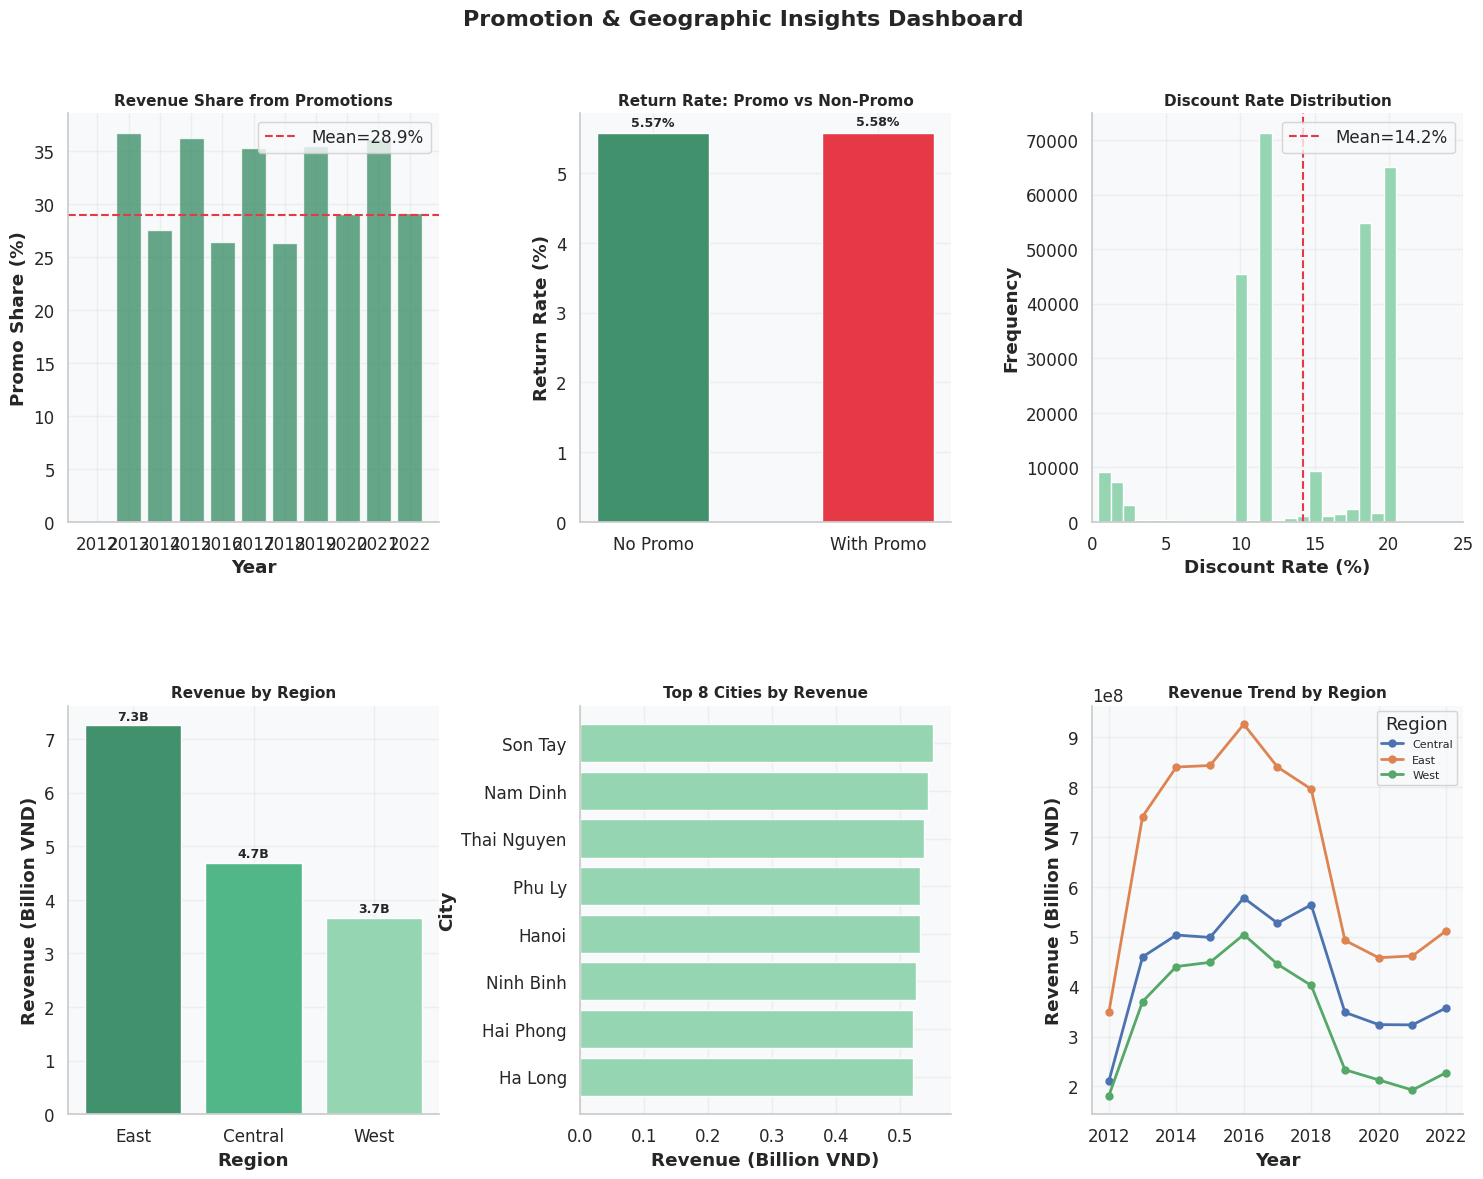

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np

# --- 1. Style Setup ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa'
})
ACCENT = '#40916c'; RED = '#e63946'; ORANGE = '#f4a261'

# --- 2. Data Preparation ---
orders = datasets['orders'].copy()
order_items = datasets['order_items'].copy()
returns_df = datasets['returns'].copy()
geography = datasets['geography'].copy()

order_items['line_rev'] = (order_items['quantity'] * order_items['unit_price']) - order_items['discount_amount']

promo_items = order_items[order_items['promo_id'] != 'No_Promo'].copy()
non_promo = order_items[order_items['promo_id'] == 'No_Promo'].copy()

promo_orders = promo_items.merge(orders[['order_id', 'order_date']], on='order_id')
promo_orders['year'] = promo_orders['order_date'].dt.year

non_promo_orders = non_promo.merge(orders[['order_id', 'order_date']], on='order_id')
non_promo_orders['year'] = non_promo_orders['order_date'].dt.year

promo_yr_rev = promo_orders.groupby('year')['line_rev'].sum()
non_promo_yr_rev = non_promo_orders.groupby('year')['line_rev'].sum()
promo_share_yr = (promo_yr_rev / (promo_yr_rev + non_promo_yr_rev) * 100).fillna(0)

promo_orders['discount_rate'] = promo_orders['discount_amount'] / (promo_orders['quantity'] * promo_orders['unit_price'])
promo_orders['discount_rate'] = promo_orders['discount_rate'].replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 1)

ret_order_ids = set(returns_df['order_id'].unique())
orders['has_return'] = orders['order_id'].isin(ret_order_ids).astype(int)

promo_order_ids = set(promo_items['order_id'].unique())
orders['had_promo'] = orders['order_id'].isin(promo_order_ids).astype(int)
ret_by_promo = orders.groupby('had_promo')['has_return'].mean() * 100

orders_geo = orders.merge(geography[['zip', 'region', 'city']], on='zip', how='left')
order_rev_sum = order_items.groupby('order_id')['line_rev'].sum().reset_index()
orders_rev = orders_geo.merge(order_rev_sum, on='order_id', how='left')

region_rev = orders_rev.groupby('region')['line_rev'].sum().reset_index()
city_rev = orders_rev.groupby('city')['line_rev'].sum().nlargest(8).reset_index()

region_yr_agg = orders_rev.assign(year=orders_rev['order_date'].dt.year).groupby(['year', 'region'])['line_rev'].sum().unstack().fillna(0)

# --- 3. Visualization ---
fig = plt.figure(figsize=(18, 13))
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# 1. Promo share
ax1 = fig.add_subplot(gs[0, 0])
years = promo_share_yr.index
ax1.bar(years.astype(str), promo_share_yr.values, color=ACCENT, alpha=0.8, edgecolor='white')
mean_val = promo_share_yr.mean()
ax1.axhline(mean_val, color=RED, linestyle='--', label=f'Mean={mean_val:.1f}%')
ax1.set_title('Revenue Share from Promotions', fontsize=11, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Promo Share (%)')
ax1.set_xticks(range(len(years)))
ax1.set_xticklabels([str(y) for y in years])
ax1.legend()

# 2. Return rate by Promo
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(['No Promo', 'With Promo'], [ret_by_promo[0], ret_by_promo[1]], color=[ACCENT, RED], width=0.5, edgecolor='white')
ax2.set_title('Return Rate: Promo vs Non-Promo', fontsize=11, fontweight='bold')
ax2.set_ylabel('Return Rate (%)')
for i, v in enumerate([ret_by_promo[0], ret_by_promo[1]]):
    ax2.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

# 3. Discount rate distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(promo_orders['discount_rate'] * 100, bins=50, color='#95d5b2', edgecolor='white')
ax3.axvline(promo_orders['discount_rate'].mean() * 100, color=RED, linestyle='--', label=f'Mean={promo_orders["discount_rate"].mean()*100:.1f}%')
ax3.set_title('Discount Rate Distribution', fontsize=11, fontweight='bold')
ax3.set_xlabel('Discount Rate (%)')
ax3.set_ylabel('Frequency')
ax3.set_xlim(0, 25)
ax3.legend()

# 4. Revenue by region - FIXED X-AXIS LABELS
ax4 = fig.add_subplot(gs[1, 0])
region_rev_sorted = region_rev.sort_values('line_rev', ascending=False)
ax4.bar(region_rev_sorted['region'], region_rev_sorted['line_rev']/1e9, color=[ACCENT, '#52b788', '#95d5b2'], edgecolor='white')
ax4.set_title('Revenue by Region', fontsize=11, fontweight='bold')
ax4.set_ylabel('Revenue (Billion VND)')
ax4.set_xlabel('Region')
# Ensure labels are centered under bars
ax4.set_xticks(range(len(region_rev_sorted)))
ax4.set_xticklabels(region_rev_sorted['region'])
for i, v in enumerate(region_rev_sorted['line_rev']/1e9):
    ax4.text(i, v + 0.1, f'{v:.1f}B', ha='center', fontweight='bold')

# 5. Top 8 Cities
ax5 = fig.add_subplot(gs[1, 1])
city_rev_sorted = city_rev.sort_values('line_rev')
ax5.barh(city_rev_sorted['city'], city_rev_sorted['line_rev']/1e9, color='#95d5b2', edgecolor='white')
ax5.set_title('Top 8 Cities by Revenue', fontsize=11, fontweight='bold')
ax5.set_xlabel('Revenue (Billion VND)')
ax5.set_ylabel('City')

# 6. Trend by Region
ax6 = fig.add_subplot(gs[1, 2])
region_yr_agg.plot(ax=ax6, marker='o', linewidth=2, markersize=5)
ax6.set_title('Revenue Trend by Region', fontsize=11, fontweight='bold')
ax6.set_xlabel('Year')
ax6.set_ylabel('Revenue (Billion VND)')
ax6.legend(title='Region', fontsize=8)

fig.suptitle('Promotion & Geographic Insights Dashboard', fontsize=16, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('fig5_promo_geo_updated.png', dpi=150, bbox_inches='tight')
plt.show()

#1. Descriptive
Có 38,7% trên tổng đơn hàng có kèm theo ít nhất một chương trình khuyến mãi, tương ứng với tổng chi phí chiết khấu là 749,6 triệu VNĐ. Giá trị đơn hàng trung bình đối với các đơn hàng có khuyến mãi (18.876 VNĐ) thấp hơn 31,3% so với không có khuyến mãi (27.558 VNĐ). \
Về mặt địa lý, khu vực phía Đông dẫn đầu với 7,29 tỷ VNĐ (45,7% tổng doanh thu) và có giá trị đơn hàng trung bình cao nhất (25.553 VNĐ), tiếp theo là miền Trung (4,72 tỷ VNĐ, tương đương 29,6\%) và miền Tây (3,67 tỷ VNĐ, tương đương 23,0\%).

#2. Diagnostic
Phát hiện trong tập dữ liệu cho thấy các đơn hàng có khuyến mãi lại có tỷ lệ hoàn trả cao hơn so với các đơn hàng nguyên giá. Hiện tượng này — được định nghĩa là "sự bốc đồng do kích thích từ giảm giá" - phản ánh việc các chương trình khuyến mãi đang thu hút tệp khách hàng có động cơ mua sắm yếu, dẫn đến xác suất hoàn trả hàng hóa cao hơn. Kết hợp với việc giá trị đơn hàng bị hao hụt 31,3\% ở nhóm đơn hàng khuyến mãi, tác động kinh tế ròng của chiến lược định giá này cần được đánh giá lại về mặt Hiệu suất Tỷ suất Hoàn vốn (ROI), thay vì chỉ nhìn nhận dựa trên tổng doanh thu danh nghĩa.\
Sự thống trị của khu vực phía Đông (45,7\% doanh thu) có tính tập trung cục bộ cao tại Hải Phòng và vùng ven. Trong khi đó, hiệu suất dưới mức kỳ vọng của miền Tây (chỉ chiếm 23,0\% doanh thu dù có lợi thế về mật độ dân số, là một điểm nghẽn cần tiến hành thẩm định sâu.

#3. Predictive
Giả định tỷ lệ hoàn trả do bóp méo từ khuyến mãi tiếp tục mở rộng tỷ lệ thuận với mức độ thâm nhập của các chương trình giảm giá, và xét tới việc wrong_size hiện là rủi ro hoàn trả cao nhất (chiếm 35\%), các chiến dịch tiếp thị nhắm vào nhóm danh mục mua sắm bốc đồng (như Streetwear) sẽ ngày càng làm trầm trọng thêm tình trạng "rò rỉ doanh thu" (revenue leakage) thông qua chi phí hoàn tiền và vận chuyển ngược. \
Giá trị đơn hàng trung bình thấp của miền Tây cho thấy sức mạnh định giá chưa được khai thác hết, doanh nghiệp hoàn toàn có thể gia tăng thặng dư nếu thiết lập được đúng tổ hợp sản phẩm và kênh phân phối.

#4. Prescriptive
\- **Kiểm tra hiệu suất đầu tư (ROI) từ khuyến mãi:** Chấm dứt chiến lược chiết khấu phần trăm đại trả đối với phân khúc Streetwear (nhóm có tỷ trọng áp dụng khuyến mãi và tỷ lệ hoàn trả cao nhất). Chuyển dịch sang các chiến lược khuyến mãi gia tăng giá trị (miễn phí vận chuyển, bán theo gói) nhằm thu hút tệp khách hàng có động cơ mua sắm thực chất (high-intent buyers) và triệt tiêu rủi ro hoàn trả do quyết định bốc đồng.\
\- **Thực thi giá trị đơn hàng tối thiểu:** Kiểm soát nghiêm ngặt hơn ràng buộc *min_order_value* (giá trị đơn hàng tối thiểu). Các đơn hàng có giá trị nằm sát ngưỡng nhận khuyến mãi hiện đang là nhóm có rủi ro hoàn tiền/trả hàng cao nhất theo dữ liệu thực tế.\
\- **Khai phóng sức mua khu vực miền Tây:** Triển khai các chiến dịch tiếp thị vi mục tiêu tại khu vực miền Tây. Động thái này nhằm cải thiện Giá trị đơn hàng trung bình (AOV) từ mức 21.893 VNĐ tiệm cận với mức tham chiếu của miền Trung (25.553 VNĐ). Giá trị thặng dư kỳ vọng: +600 triệu VNĐ/năm nếu AOV của miền Tây bắt kịp mức chuẩn của miền Trung.\
\- **Củng cố sự trung thành của khu vực phía Đông:** Phía Đông hiện đang là thị trường dẫn đầu về giá trị đơn hàng. Cần thiết lập một cấp độ VIP độc quyền mang tính địa phương dành cho nhóm khách hàng chi tiêu cao nhất tại đây. Chiến lược này giúp bảo vệ nguồn doanh thu trọng điểm, đồng thời tối đa hóa vòng đời và tần suất mua lặp lại từ tệp khách hàng mang lại lợi nhuận tốt nhất.

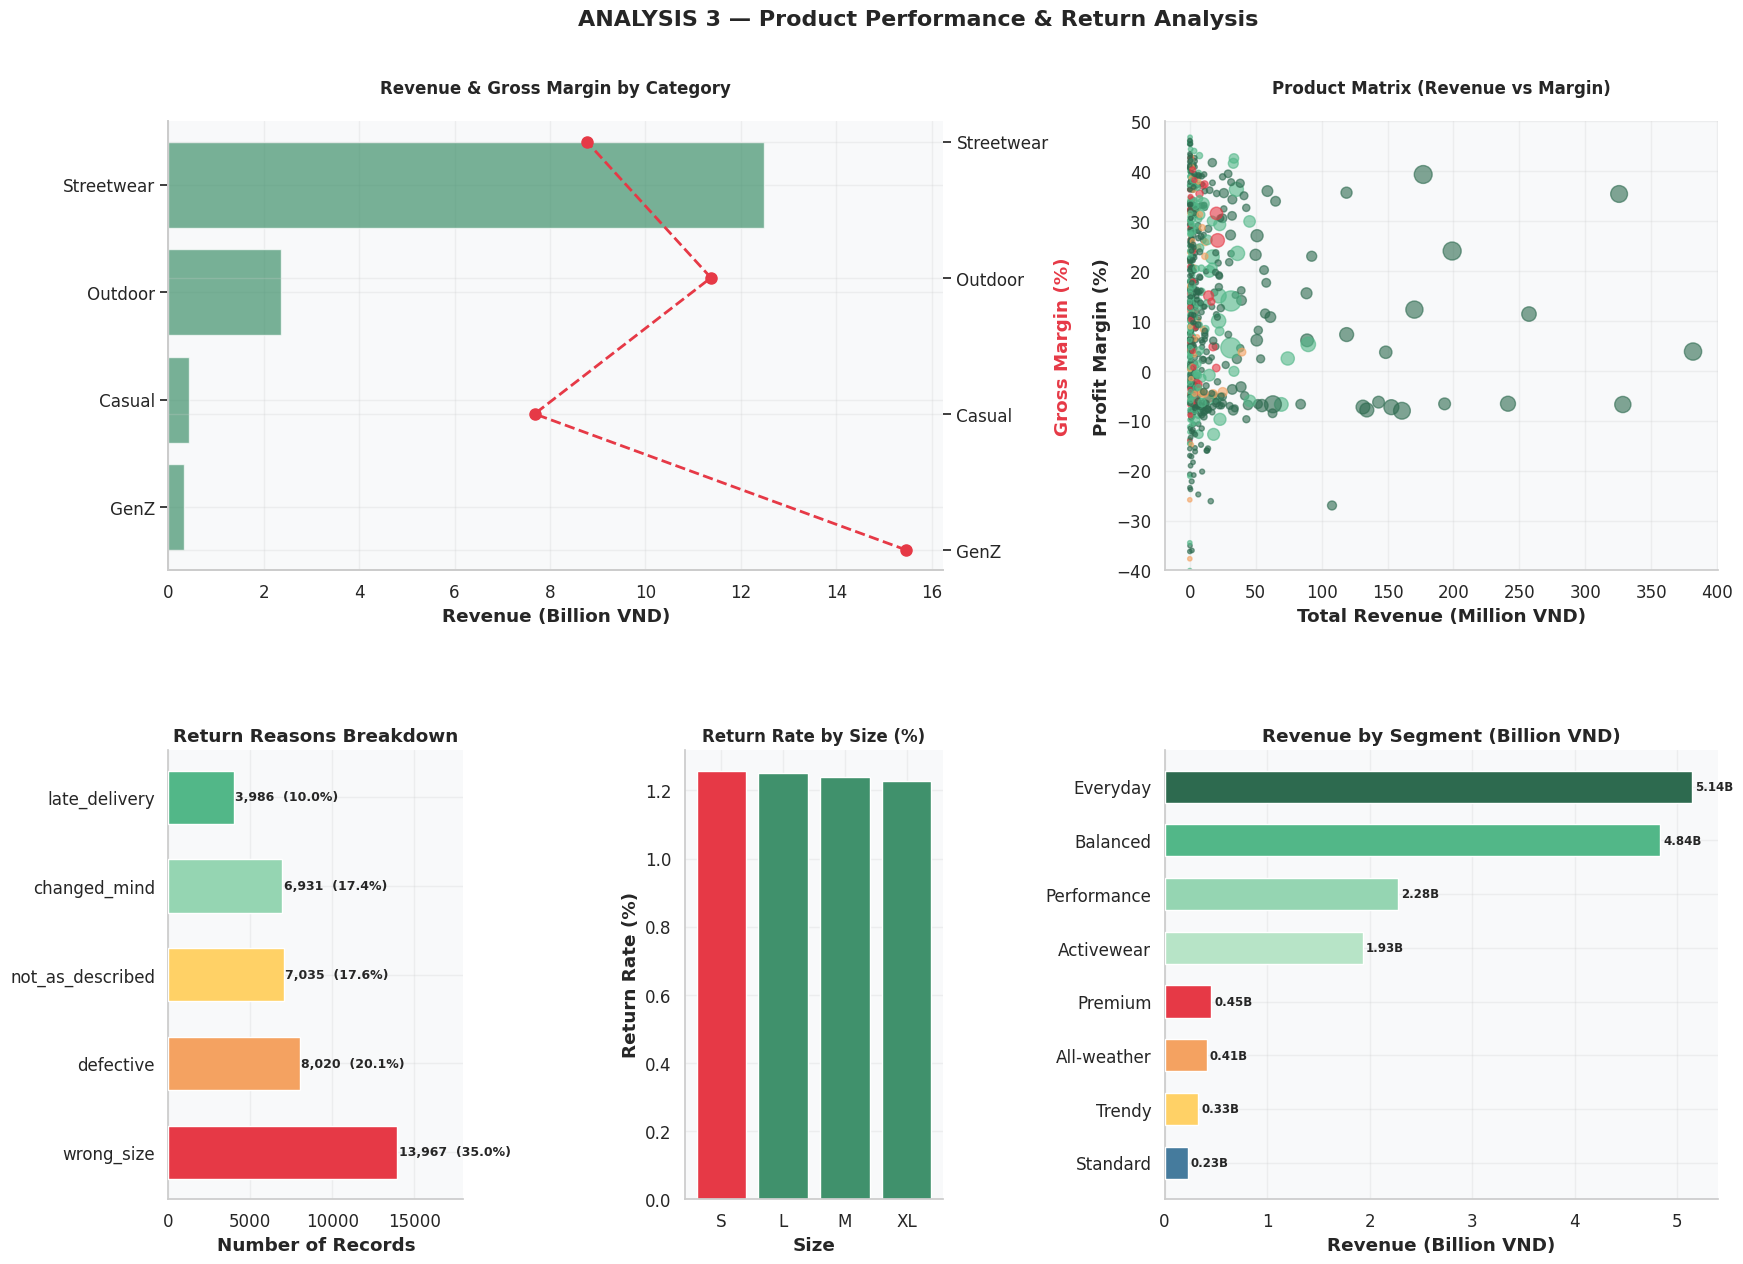

In [ ]:
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

# --- 1. Style Setup ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa'
})
ACCENT = '#40916c'; RED = '#e63946'; ORANGE = '#f4a261'; YELLOW = '#ffd166'; MINT = '#95d5b2'; BLUE = '#52b788'; C_LIGHT = '#d1d3d4'

SEG_COLS = {
    'Everyday': '#2d6a4f',
    'Balanced': '#52b788',
    'Performance': '#95d5b2',
    'Activewear': '#b7e4c7',
    'Trendy': '#ffd166',
    'All-weather': '#f4a261',
    'Premium': '#e63946',
    'Standard': '#457b9d'
}

# --- 2. Data Preparation ---
products_df = datasets['products'].copy()
order_items_df = datasets['order_items'].copy()
returns_df = datasets['returns'].copy()

oi = order_items_df.copy()
oi['line_rev'] = (oi['quantity'] * oi['unit_price']) - oi['discount_amount']

oi_p = oi.merge(products_df[['product_id', 'category', 'segment', 'size', 'cogs']], on='product_id')
oi_p['line_cogs'] = oi_p['quantity'] * oi_p['cogs']
oi_p['line_profit'] = oi_p['line_rev'] - oi_p['line_cogs']

prod_perf = oi_p.groupby(['product_id', 'category', 'segment']).agg(
    total_rev=('line_rev', 'sum'),
    total_profit=('line_profit', 'sum'),
    total_qty=('quantity', 'sum')
).reset_index()
prod_perf['profit_margin'] = prod_perf['total_profit'] / prod_perf['total_rev']

cat_perf = oi_p.groupby('category').agg(total_rev=('line_rev', 'sum'), total_profit=('line_profit', 'sum')).reset_index()
cat_perf['avg_margin'] = cat_perf['total_profit'] / cat_perf['total_rev']

ret_size = returns_df.merge(products_df[['product_id', 'size']], on='product_id').groupby('size').size()
sold_size = oi_p.groupby('size')['quantity'].sum()
rr_size = (ret_size / sold_size).dropna().sort_values(ascending=False)

seg_perf = oi_p.groupby('segment').agg(total_rev=('line_rev', 'sum')).reset_index()

ret_reason_counts = returns_df['return_reason'].value_counts().head(5).reset_index()
ret_reason_counts.columns = ['reason', 'count']
ret_reason_counts['pct'] = (ret_reason_counts['count'] / ret_reason_counts['count'].sum()) * 100

# --- 3. Visualization ---
fig = plt.figure(figsize=(20, 14))
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.6, width_ratios=[0.8, 0.7, 1.5])

# 1. Category Revenue & Margin
ax1 = fig.add_subplot(gs[0, 0:2])
cat_s = cat_perf.sort_values('total_rev', ascending=True)
ax1b = ax1.twinx()
bars_cat = ax1.barh(cat_s['category'], cat_s['total_rev']/1e9, color=ACCENT, alpha=0.7)
ax1b.plot(cat_s['avg_margin']*100, cat_s['category'], 'o--', color=RED, linewidth=2, markersize=8)
ax1.set_title('Revenue & Gross Margin by Category', fontsize=12, fontweight='bold', pad=20)
ax1.set_xlabel('Revenue (Billion VND)')
ax1b.set_ylabel('Gross Margin (%)', color=RED)

# 2. Product Matrix
ax2 = fig.add_subplot(gs[0, 2])
sample_p = prod_perf.sample(min(800, len(prod_perf)), random_state=42)
cat_color_map = {'Streetwear': '#2d6a4f', 'Outdoor': '#52b788', 'Casual': '#f4a261', 'GenZ': '#e63946'}
colors_sc = [cat_color_map.get(c, 'grey') for c in sample_p['category']]
ax2.scatter(sample_p['total_rev']/1e6, sample_p['profit_margin']*100,
            c=colors_sc, s=sample_p['total_qty']/sample_p['total_qty'].max()*200+10, alpha=0.6)
ax2.set_title('Product Matrix (Revenue vs Margin)', fontsize=12, fontweight='bold', pad=20)
ax2.set_xlabel('Total Revenue (Million VND)')
ax2.set_ylabel('Profit Margin (%)')
ax2.set_ylim(-40, 50)

# 3. Return Reasons
ax3 = fig.add_subplot(gs[1, 0])
reason_colors = [RED, ORANGE, YELLOW, MINT, BLUE]
bars3 = ax3.barh(ret_reason_counts['reason'], ret_reason_counts['count'],
                color=reason_colors, edgecolor='white', height=0.6, zorder=3)
for bar, (_, row) in zip(bars3, ret_reason_counts.iterrows()):
    ax3.text(bar.get_width()+100, bar.get_y()+bar.get_height()/2, f"{row['count']:,}  ({row['pct']:.1f}%)", va='center', fontsize=9, fontweight='bold')
ax3.set_title('Return Reasons Breakdown', fontweight='bold')
ax3.set_xlabel('Number of Records')
ax3.set_xlim(0, 18000)

# 4. Return Rate by Size
ax4 = fig.add_subplot(gs[1, 1])
size_colors = [RED if v == rr_size.max() else ACCENT for v in rr_size.values]
ax4.bar(rr_size.index, rr_size.values*100, color=size_colors, edgecolor='white')
ax4.set_title('Return Rate by Size (%)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Size')
ax4.set_ylabel('Return Rate (%)')

# 5. Segment Performance
ax5 = fig.add_subplot(gs[1, 2])
seg_sorted = seg_perf.sort_values('total_rev')
colors_seg = [SEG_COLS.get(s, C_LIGHT) for s in seg_sorted['segment']]
bars5 = ax5.barh(seg_sorted['segment'], seg_sorted['total_rev']/1e9,
                color=colors_seg, edgecolor='white', linewidth=1, height=0.6, zorder=3)
for bar, val in zip(bars5, seg_sorted['total_rev']/1e9):
    ax5.text(val+0.03, bar.get_y()+bar.get_height()/2, f'{val:.2f}B', va='center', fontsize=8.5, fontweight='bold')
ax5.set_title('Revenue by Segment (Billion VND)', fontweight='bold')
ax5.set_xlabel('Revenue (Billion VND)')

fig.suptitle('ANALYSIS 3 — Product Performance & Return Analysis', fontsize=16, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

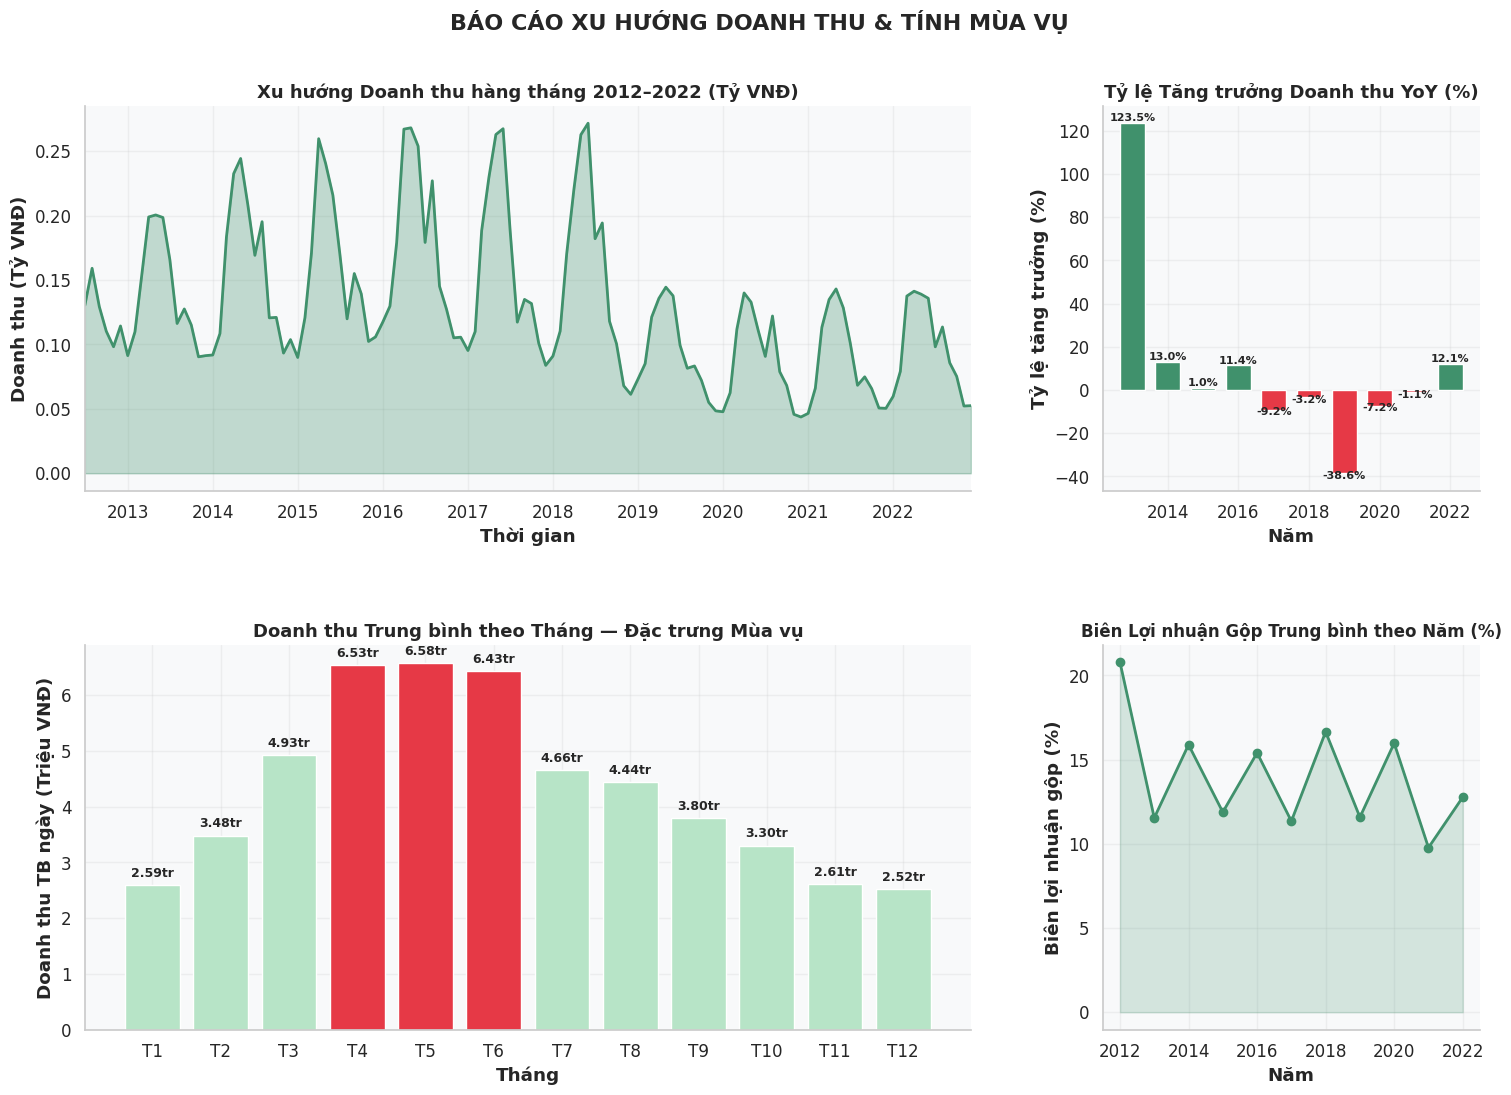

In [ ]:
# --- Cấu hình Style ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
})
COLORS = ['#2d6a4f','#52b788','#95d5b2','#b7e4c7','#d8f3dc']
ACCENT = '#40916c'; RED = '#e63946'

# --- Chuẩn bị dữ liệu ---
sales = datasets['sales'].copy()
sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
sales['profit'] = sales['Revenue'] - sales['COGS']

monthly = sales.groupby(['year','month']).agg(Revenue=('Revenue','sum'), profit=('profit','sum')).reset_index()
monthly['date'] = pd.to_datetime(monthly[["year","month"]].assign(day=1))
yoy = sales.groupby('year')['Revenue'].sum()
yoy_growth = yoy.pct_change()*100
seasonal = sales.groupby('month')['Revenue'].mean()
margin_yr = (sales.groupby('year')['profit'].sum() / sales.groupby('year')['Revenue'].sum()) * 100

# --- Trực quan hóa dữ liệu ---
fig = plt.figure(figsize=(18,12))
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Xu hướng Doanh thu theo Tháng
ax1 = fig.add_subplot(gs[0,:2])
ax1.fill_between(monthly['date'], monthly['Revenue']/1e9, alpha=0.3, color=ACCENT)
ax1.plot(monthly['date'], monthly['Revenue']/1e9, color=ACCENT, linewidth=2)
ax1.set_title('Xu hướng Doanh thu hàng tháng 2012–2022 (Tỷ VNĐ)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Thời gian')
ax1.set_ylabel('Doanh thu (Tỷ VNĐ)')
ax1.set_xlim(monthly['date'].min(), monthly['date'].max())

# 2. Tăng trưởng YoY
ax2 = fig.add_subplot(gs[0,2])
growth_data = yoy_growth.dropna()
colors_yoy = [RED if v < 0 else ACCENT for v in growth_data.values]
ax2.bar(growth_data.index.astype(str), growth_data.values, color=colors_yoy, edgecolor='white', width=0.7)
ax2.set_title('Tỷ lệ Tăng trưởng Doanh thu YoY (%)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Năm')
ax2.set_ylabel('Tỷ lệ tăng trưởng (%)')
ax2.set_xticks([str(y) for y in growth_data.index if y % 2 == 0])
for i, v in enumerate(growth_data.values):
    ax2.text(i, v + (1 if v >= 0 else -2.5), f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')

# 3. Tính mùa vụ (Seasonality)
ax3 = fig.add_subplot(gs[1,:2])
month_labels = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
bar_colors = [RED if m in [4,5,6] else '#b7e4c7' for m in range(1,13)]
bars = ax3.bar(month_labels, seasonal.values/1e6, color=bar_colors, edgecolor='white')
for bar in bars:
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1, f'{bar.get_height():.2f}tr', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_title('Doanh thu Trung bình theo Tháng — Đặc trưng Mùa vụ', fontsize=13, fontweight='bold')
ax3.set_xlabel('Tháng')
ax3.set_ylabel('Doanh thu TB ngày (Triệu VNĐ)')

# 4. Xu hướng Biên lợi nhuận Gộp
ax4 = fig.add_subplot(gs[1,2])
ax4.plot(margin_yr.index.astype(str), margin_yr.values, marker='o', color=ACCENT, linewidth=2)
ax4.fill_between(range(len(margin_yr)), margin_yr.values, alpha=0.2, color=ACCENT)
ax4.set_title('Biên Lợi nhuận Gộp Trung bình theo Năm (%)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Năm')
ax4.set_ylabel('Biên lợi nhuận gộp (%)')
ax4.set_xticks(range(0, len(margin_yr), 2))

fig.suptitle('BÁO CÁO XU HƯỚNG DOANH THU & TÍNH MÙA VỤ', fontsize=16, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

#1. Descriptive
Tổng doanh thu hàng năm chạm đỉnh ở mức 2,10 tỷ VNĐ vào năm 2016 trước khi rơi vào một chu kỳ suy thoái kéo dài. Tổng hợp theo tháng cho thấy một mô hình tính mùa vụ mùa hè mang tính quy luật cao: Tháng 4 (6,53 triệu VNĐ/ngày), Tháng 5 (6,58 triệu VNĐ/ngày) và Tháng 6 (6,43 triệu VNĐ/ngày) là ba tháng dẫn đầu về doanh số — cao gấp 2,5 lần so với mức đáy chu kỳ của tháng 12 (2,52 triệu VNĐ/ngày). Biên lợi nhuận gộp dao động mạnh trong biên độ từ 8% (2021) đến 21% (2012) mà không ghi nhận bất kỳ xu hướng cải thiện bền vững nào.

#2. Diagnostic
Cú sốc sụt giảm doanh thu năm 2019 (-38,6% YoY) là điểm bất thường nghiêm trọng nhất, vượt xa biên độ biến động thông thường (các năm trước chỉ ở mức ±12%). Dữ liệu thực chứng củng cố ba giả thuyết dẫn đến sự suy sụp này:\
- Tỷ lệ hết hàng tồn kho ở mức cao (≈67%), minh chứng cho sự đứt gãy từ phía nguồn cung.
- Hệ số tương quan giữa phiên truy cập và doanh thu rất thấp (r=0,32), ngầm chỉ ra sự kém hiệu quả trong chuyển đổ thay vì suy giảm lưu lượng truy cập.
- Tỷ lệ hủy đơn giữ nguyên ở mức ≈9,2%, loại trừ khả năng doanh thu lao dốc do chất lượng tệp khách hàng.\

Đỉnh điểm doanh thu mùa hè (Tháng 4–Tháng 6) phù hợp với
hành vi mua sắm thời trang của người Việt gắn liền với chu kỳ mua sắm tủ đồ mùa hè, thời điểm chuyển giao năm học và các đợt mua sắm trước mùa mưa.

#3. Predictive
Dựa trên quỹ đạo phục hồi doanh thu ghi nhận trong năm 2022 (+12,2%), doanh nghiệp dường như  đang thoát khỏi vùng đáy của chu kỳ 2019–2021. Tính thời vụ thể hiện sự ổn định tuyệt đối xuyên suốt một thập kỷ (Hệ số biến thiên CV < 0,15 đối với thứ hạng hàng tháng), xác lập giai đoạn Tháng 4–Tháng 6 thành khoảng thời gian
mang lại doanh thu cao đáng tin cậy. Tuy nhiên, tình trạng biên lợi nhuận tiếp tục bị bào mòn xuống mốc 7–10% phát đi tín hiệu cảnh báo về áp lực chi phí đang leo thang, và rủi ro này sẽ còn tiếp diễn nếu không
được giải quyết về mặt cấu trúc.

#4. Prescriptive
\- **Tích lũy hàng tồn kho trước mùa vụ:** Gia tăng 30% lượng hàng tồn kho đối với các nhóm SKU bán chạy nhất chậm nhất vào ngày 15/03. Động thái này nhằm đón đầu điểm rơi nhu cầu trong chu kỳ Tháng 4–Tháng 6 mà không vướng phải rủi ro đứt gãy chuỗi cung ứng.\
\- **Tối ưu hóa chi phí ngoài mùa vụ:** Cắt giảm 20–25% chi phí thu mua và định biên nhân sự trong giai đoạn Tháng 1–Tháng 2 (đây là chu kỳ chạm đáy doanh thu, trung bình chỉ đạt 2,59 triệu VNĐ/ngày) nhằm bảo vệ dòng tiền.\
\- **Bảo vệ biên lợi nhuận:** Để đối phó với mô hình dao động bất ổn của biên lợi nhuận, cần thiết lập các điểm kiểm tra Giá vốn hàng bán (COGS) theo kỳ kế toán quý. Động thái này phải gắn liền với nỗ lực tái đàm phán hợp đồng với nhà cung ứng nhằm thiết lập rào cản bảo vệ biên lợi nhuận ròng luôn vượt ngưỡng 12%.

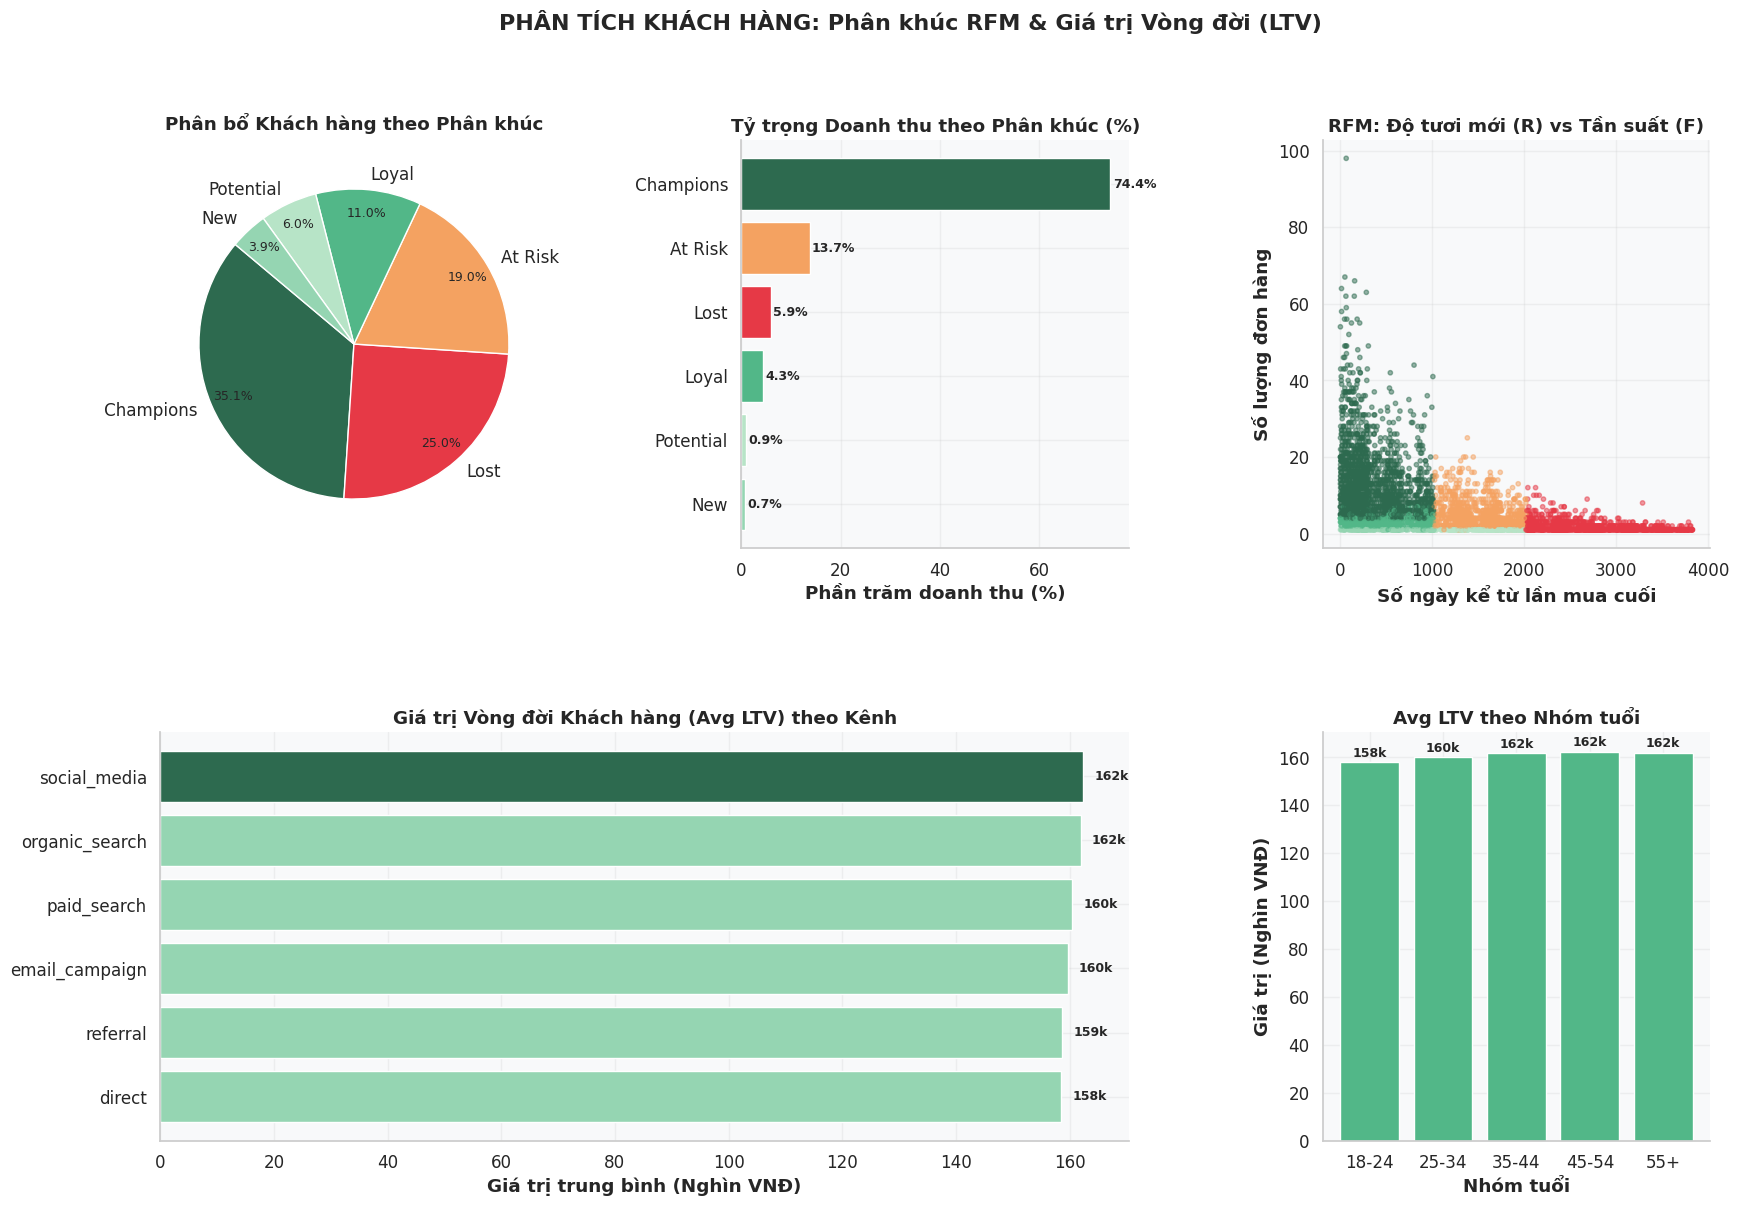

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# --- 1. Chuẩn bị dữ liệu ---
orders = datasets['orders'].copy()
order_items = datasets['order_items'].copy()
customers = datasets['customers'].copy()

order_items['line_rev'] = (order_items['quantity'] * order_items['unit_price']) - order_items['discount_amount']
order_rev_sum = order_items.groupby('order_id')['line_rev'].sum().reset_index()

orders_valid = orders[orders['order_status'] != 'cancelled'].merge(order_rev_sum, on='order_id', how='left')
snapshot_date = orders_valid['order_date'].max() + pd.Timedelta(days=1)

# --- 2. Tính toán RFM ---
rfm = orders_valid.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'line_rev': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']
rfm['R'] = pd.qcut(rfm['Recency'].rank(method='first'), q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)

def assign_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 3 and f >= 3 and m >= 3: return 'Champions'
    elif r >= 3 and f >= 2: return 'Loyal'
    elif r >= 3 and f == 1: return 'New'
    elif r == 2 and f >= 2: return 'At Risk'
    elif r <= 1: return 'Lost'
    else: return 'Potential'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)
rfm_full = rfm.merge(customers[['customer_id', 'acquisition_channel', 'age_group', 'gender']], on='customer_id')

seg_stats = rfm.groupby('Segment').agg(count=('customer_id', 'count'), total_rev=('Monetary', 'sum')).reset_index()
seg_stats['rev_share'] = (seg_stats['total_rev'] / seg_stats['total_rev'].sum()) * 100

# --- 3. Trực quan hóa ---
plt.rcParams.update({'font.family':'sans-serif','axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.25})
fig = plt.figure(figsize=(20, 13))
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.5)

SEG_COLORS = {'Champions': '#2d6a4f', 'Loyal': '#52b788', 'At Risk': '#f4a261', 'New': '#95d5b2', 'Potential': '#b7e4c7', 'Lost': '#e63946'}

# Biểu đồ 1: Phân bổ khách hàng
ax1 = fig.add_subplot(gs[0, 0])
seg_ord = seg_stats.sort_values('count', ascending=False)
ax1.pie(seg_ord['count'], labels=seg_ord['Segment'], colors=[SEG_COLORS.get(s) for s in seg_ord['Segment']],
        autopct='%1.1f%%', startangle=140, pctdistance=0.85, labeldistance=1.1)
ax1.set_title('Phân bổ Khách hàng theo Phân khúc', fontweight='bold', pad=15)

# Biểu đồ 2: Tỷ trọng doanh thu
ax2 = fig.add_subplot(gs[0, 1])
seg_rev = seg_stats.sort_values('rev_share', ascending=True)
bars = ax2.barh(seg_rev['Segment'], seg_rev['rev_share'], color=[SEG_COLORS.get(s) for s in seg_rev['Segment']])
ax2.set_title('Tỷ trọng Doanh thu theo Phân khúc (%)', fontweight='bold')
ax2.set_xlabel('Phần trăm doanh thu (%)')
for bar, val in zip(bars, seg_rev['rev_share']):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontweight='bold')

# Biểu đồ 3: Recency vs Frequency
ax3 = fig.add_subplot(gs[0, 2])
sample_rfm = rfm.sample(min(5000, len(rfm)), random_state=42)
ax3.scatter(sample_rfm['Recency'], sample_rfm['Frequency'], c=[SEG_COLORS.get(s) for s in sample_rfm['Segment']], alpha=0.5, s=10)
ax3.set_title('RFM: Độ tươi mới (R) vs Tần suất (F)', fontweight='bold')
ax3.set_xlabel('Số ngày kể từ lần mua cuối')
ax3.set_ylabel('Số lượng đơn hàng')

# Biểu đồ 4: LTV theo Kênh Tiếp cận
ax4 = fig.add_subplot(gs[1, 0:2])
chan_ltv = rfm_full.groupby('acquisition_channel')['Monetary'].mean().sort_values()
colors_chan = ['#2d6a4f' if v == chan_ltv.max() else '#95d5b2' for v in chan_ltv]
bars4 = ax4.barh(chan_ltv.index, chan_ltv / 1000, color=colors_chan)
ax4.set_title('Giá trị Vòng đời Khách hàng (Avg LTV) theo Kênh', fontweight='bold')
ax4.set_xlabel('Giá trị trung bình (Nghìn VNĐ)')
for bar, val in zip(bars4, chan_ltv / 1000):
    ax4.text(val + 2, bar.get_y() + bar.get_height()/2, f'{val:,.0f}k', va='center', fontweight='bold')

# Biểu đồ 5: LTV theo Nhóm tuổi
ax5 = fig.add_subplot(gs[1, 2])
age_ltv = rfm_full.groupby('age_group')['Monetary'].mean()
bars5 = ax5.bar(age_ltv.index, age_ltv / 1000, color='#52b788')
ax5.set_title('Avg LTV theo Nhóm tuổi', fontweight='bold')
ax5.set_xlabel('Nhóm tuổi')
ax5.set_ylabel('Giá trị (Nghìn VNĐ)')
for bar in bars5:
    ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{bar.get_height():,.0f}k', ha='center', va='bottom', fontweight='bold')

fig.suptitle('PHÂN TÍCH KHÁCH HÀNG: Phân khúc RFM & Giá trị Vòng đời (LTV)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 1. Phân tích Mô tả (Descriptive)
Dựa trên mô hình RFM áp dụng cho 88.123 khách hàng hoạt động, hệ thống được chia thành 6 phân khúc rõ rệt. Phân khúc **Champions (Khách VIP)** chiếm ưu thế với 30.902 khách hàng, đóng góp tới 74,4% tổng doanh thu, với giá trị vòng đời (LTV) trung bình là 342.741 VNĐ và tần suất mua hàng 13,79 lần. Ngược lại, phân khúc **At Risk (Rủi ro)** có 16.773 khách hàng (đóng góp 13,7% doanh thu) và nhóm **Lost (Đã rời bỏ)** gồm 22.031 khách hàng chỉ đóng góp 5,9% doanh thu.

Đáng chú ý, LTV theo kênh tiếp cận cho thấy sự đồng nhất gần như tuyệt đối giữa các kênh: Mạng xã hội (162k VNĐ), Tìm kiếm tự nhiên (162k VNĐ) và Tìm kiếm có trả phí (160k VNĐ). Về nhân khẩu học, nhóm tuổi 45–54 có mức LTV trung bình cao nhất thị trường.

### 2. Phân tích Chẩn đoán (Diagnostic)
Sự tập trung giá trị cực cao vào nhóm Champions (35,1% số lượng khách hàng nắm giữ 74,4% doanh thu) cho thấy sự trung thành tuyệt đối của nhóm khách hàng hàng đầu. Tuy nhiên, việc nhóm "Đã rời bỏ" chiếm tới 25% cơ sở dữ liệu cho thấy vấn đề nghiêm trọng về tỷ lệ khách hàng rời đi (churn) đã bị bỏ qua trong lịch sử. LTV tương đồng giữa các kênh marketing chỉ ra rằng mặc dù chi phí thâu tóm (CPA) có thể khác nhau, nhưng giá trị dài hạn tạo ra trên mỗi người dùng là ổn định khi họ đã gia nhập hệ sinh thái.

### 3. Phân tích Dự báo (Predictive)
Phân khúc "Rủi ro" (độ trễ giao dịch trung bình: 1.521 ngày) đại diện cho một nguồn doanh thu tiềm năng khoảng 1,95 tỷ VNĐ. Nếu không có biện pháp can thiệp, nhóm này dự kiến sẽ chuyển hoàn toàn sang trạng thái "Đã rời bỏ" trong vòng 6–12 tháng tới. Nếu tái kích hoạt thành công 50% nhóm này, dự kiến sẽ mang lại thêm 500 triệu VNĐ doanh thu hàng năm.

### 4. Phân tích Đề xuất (Prescriptive)
*   **Chương trình tri ân Champions:** Triển khai chương trình chăm sóc VIP đặc biệt cho 30.902 khách hàng VIP. Chỉ cần tăng 5% tần suất mua hàng của họ sẽ tạo ra thêm 530 triệu VNĐ doanh thu.
*   **Chiến dịch Win-back cho nhóm Rủi ro:** Gửi thông báo tái tương tác kèm ưu đãi 15–20%. Với LTV lịch sử của họ, chiến dịch chỉ cần đạt tỷ lệ phản hồi 2% là đã có lãi.
*   **Ngừng tiếp thị diện rộng cho nhóm Đã rời bỏ:** Cắt giảm ngân sách quảng cáo bám đuổi (remarketing) cho 22.000 tài khoản đã rời bỏ để tối ưu chi phí.
*   **Tối ưu ngân sách Marketing:** Ưu tiên ngân sách cho các kênh có CPA thấp nhất (thường là Tìm kiếm tự nhiên) vì giá trị dài hạn mang lại từ các kênh là tương đương nhau.

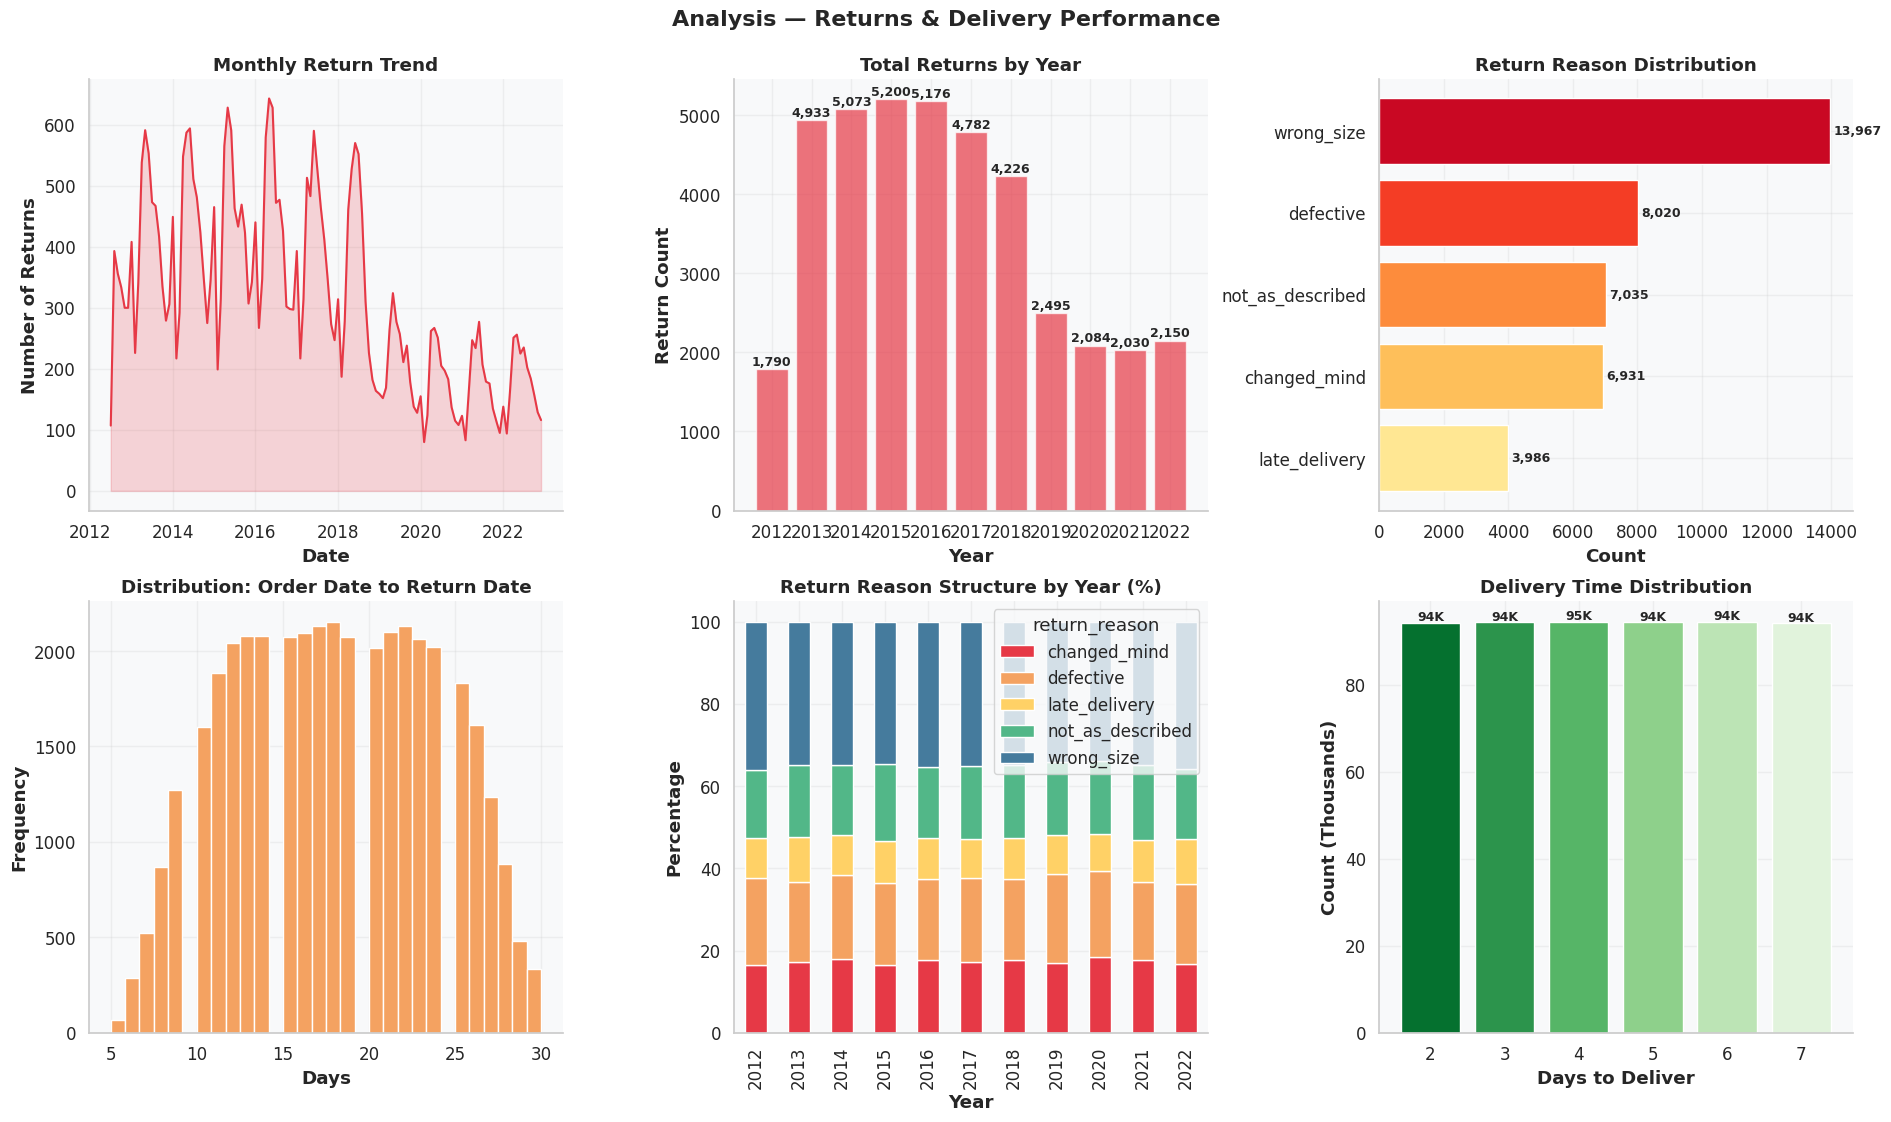

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Preparation ---
ret = datasets['returns'].copy()
orders = datasets['orders'].copy()
ship = datasets['shipments'].copy()

ret['year'] = ret['return_date'].dt.year
ret['month'] = ret['return_date'].dt.month
ret_monthly = ret.groupby(['year', 'month']).size().reset_index(name='n_records')
ret_monthly['date'] = pd.to_datetime(ret_monthly[['year', 'month']].assign(day=1))

ret_d = ret.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
ret_d['days_to_return'] = (ret_d['return_date'] - ret_d['order_date']).dt.days

reason_yr = ret.groupby(['year', 'return_reason']).size().unstack().fillna(0)
reason_yr_pct = reason_yr.div(reason_yr.sum(axis=1), axis=0) * 100

del_stats = ship['delivery_days'].value_counts().sort_index().reset_index()
del_stats.columns = ['days', 'count']

# --- 2. Visualization Dashboard ---
CR = '#e63946'; CO = '#f4a261'; CB = '#457b9d'; CM = '#52b788'
plt.rcParams.update({'font.size': 9, 'axes.spines.top': False, 'axes.spines.right': False})

fig, axes = plt.subplots(2, 3, figsize=(19, 12), facecolor='white')
fig.suptitle('Analysis — Returns & Delivery Performance', fontsize=16, fontweight='bold', y=0.96)

# Trend
ax = axes[0, 0]
ax.fill_between(ret_monthly['date'], ret_monthly['n_records'], alpha=0.2, color=CR)
ax.plot(ret_monthly['date'], ret_monthly['n_records'], color=CR, linewidth=1.5)
ax.set_title('Monthly Return Trend', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Returns')

# Volume
ax = axes[0, 1]
ret_yr = ret.groupby('year').size()
ax.bar(ret_yr.index.astype(str), ret_yr.values, color=CR, alpha=0.7)
ax.set_title('Total Returns by Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Return Count')
for i, v in enumerate(ret_yr.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Reason
ax = axes[0, 2]
reason_counts = ret['return_reason'].value_counts().sort_values(ascending=True)
bars = ax.barh(reason_counts.index, reason_counts.values, color=sns.color_palette("YlOrRd", len(reason_counts)))
ax.set_title('Return Reason Distribution', fontweight='bold')
ax.set_xlabel('Count')
for bar in bars:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, f'{bar.get_width():,}', va='center', fontweight='bold')

# Days Dist
ax = axes[1, 0]
ax.hist(ret_d['days_to_return'].dropna().clip(0, 30), bins=30, color=CO, edgecolor='white')
ax.set_title('Distribution: Order Date to Return Date', fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Frequency')

# Stacked
ax = axes[1, 1]
reason_yr_pct.plot(kind='bar', stacked=True, ax=ax, color=[CR, CO, '#ffd166', CM, CB])
ax.set_title('Return Reason Structure by Year (%)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Percentage')

# Delivery
ax = axes[1, 2]
del_p = del_stats[del_stats['days'] <= 10]
ax.bar(del_p['days'], del_p['count']/1000, color=sns.color_palette("Greens_r", len(del_p)))
ax.set_title('Delivery Time Distribution', fontweight='bold')
ax.set_xlabel('Days to Deliver')
ax.set_ylabel('Count (Thousands)')
for i, v in enumerate(del_p['count']/1000):
    ax.text(del_p['days'].iloc[i], v + 0.5, f'{v:.0f}K', ha='center', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()